# Statistical Arbitrage Experiment 2 — Basis-Native Regime Signals

## Goal

This notebook studies a BTC spot–futures basis mean-reversion strategy using **basis-native regime signals**, without relying on the external predicted-volatility overlay as the main driver.

The main questions are:

1. Can basis-native activity signals outperform the plain baseline strategy?
2. Is it better to suppress trading in high-activity regimes, or only trade in those regimes?
3. Which regime signal works best:
   - basis volatility
   - basis realized variation
   - divergence measures
   - basis absolute-move activity
4. How robust are the results to:
   - trading costs
   - entry / exit thresholds
   - lookback windows
   - more realistic execution assumptions

---

## High-level structure

- Build the merged spot / futures basis dataframe
- Add historical volatility and basis-native regime signals
- Run the baseline strategy
- Test hard filters on predicted vol / basis signals
- Run decile analysis
- Test soft scaling and high-vol-only strategies
- Sweep across multiple basis-native signals
- Perform sensitivity analysis
- Add more realistic execution constraints
- Identify the strongest practical version

In [1]:
import os
from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def _date_range_yyyymmdd(start_date: str, end_date: str) -> List[str]:
    dates = pd.date_range(start=pd.Timestamp(start_date), end=pd.Timestamp(end_date), freq="D")
    return [d.strftime("%Y%m%d") for d in dates]


def load_bucket_range(
    buckets_root: str,
    freq_min: int,
    start_date: str,
    end_date: str,
    mid_col_prefer: str = "mid_last",
    px_fallback_col: str = "px_last",
    prefix: str = "spot",
) -> pd.DataFrame:
    """
    Load bucket parquet files over a date range and return a standardized dataframe.
    """
    dates = _date_range_yyyymmdd(start_date, end_date)

    frames = []
    for d in dates:
        path = os.path.join(buckets_root, f"freq={freq_min}min", f"date={d}", "buckets.parquet")
        if not os.path.exists(path):
            continue
        df = pd.read_parquet(path)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No bucket parquet files found under {buckets_root} for [{start_date}, {end_date}]")

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    px = df[mid_col_prefer].copy() if mid_col_prefer in df.columns else pd.Series(np.nan, index=df.index)
    if px_fallback_col in df.columns:
        px = px.fillna(df[px_fallback_col])
    px = px.ffill()

    out = pd.DataFrame({
        "timestamp": pd.to_datetime(df["timestamp"], utc=True),
        f"{prefix}_mid": px.astype(float),
    })

    extra_cols = [
        "mid_last",
        "px_last",
        "vol_notional",
        "n_trades",
        "buy_ratio",
        "rel_spread_mean",
        "imbalance_mean",
    ]
    for c in extra_cols:
        if c in df.columns:
            out[f"{prefix}_{c}"] = df[c].values

    return out

In [3]:
def prepare_basis_dataframe(
    spot_buckets_root: str,
    fut_buckets_root: str,
    freq_min: int,
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    """
    Load spot and futures buckets, align on timestamp, and construct basis dataframe.
    """
    spot = load_bucket_range(
        buckets_root=spot_buckets_root,
        freq_min=freq_min,
        start_date=start_date,
        end_date=end_date,
        prefix="spot",
    )
    fut = load_bucket_range(
        buckets_root=fut_buckets_root,
        freq_min=freq_min,
        start_date=start_date,
        end_date=end_date,
        prefix="fut",
    )

    df = (
        spot.merge(fut, on="timestamp", how="inner")
            .sort_values("timestamp")
            .drop_duplicates(subset=["timestamp"], keep="last")
            .reset_index(drop=True)
    )

    df["log_spot"] = np.log(df["spot_mid"].replace(0, np.nan))
    df["log_fut"] = np.log(df["fut_mid"].replace(0, np.nan))

    df["ret_spot"] = df["log_spot"].diff()
    df["ret_fut"] = df["log_fut"].diff()

    df["basis"] = df["log_fut"] - df["log_spot"]
    df["basis_ret"] = df["basis"].diff()

    return df

In [4]:
def add_historical_vol_signal(
    df: pd.DataFrame,
    hist_horizon_min: int = 30,
    freq_min: int = 1,
    out_col: str = "hist_vol_spot_30m",
) -> pd.DataFrame:
    out = df.copy()
    W = int(round(hist_horizon_min / freq_min))
    out["ret_spot2"] = out["ret_spot"] ** 2
    out[out_col] = out["ret_spot2"].rolling(W, min_periods=W).sum()
    return out


def add_basis_specific_signals(
    df: pd.DataFrame,
    freq_min: int = 1,
    basis_vol_horizon_min: int = 30,
    div_horizon_min: int = 30,
) -> pd.DataFrame:
    out = df.copy()

    Wb = int(round(basis_vol_horizon_min / freq_min))
    Wd = int(round(div_horizon_min / freq_min))

    out["basis_vol_30m"] = out["basis_ret"].pow(2).rolling(Wb, min_periods=Wb).sum()
    out["basis_rv_30m"] = out["basis_ret"].pow(2).rolling(Wb, min_periods=Wb).sum()

    out["div_30m_mean"] = out["basis"].abs().rolling(Wd, min_periods=Wd).mean()
    out["div_30m_max"] = out["basis"].abs().rolling(Wd, min_periods=Wd).max()

    return out

In [5]:
def merge_predicted_vol_signal(
    df: pd.DataFrame,
    pred_df: pd.DataFrame,
    pred_col: str,
    timestamp_col: str = "timestamp",
    out_col: str = "pred_vol_spot_30m",
) -> pd.DataFrame:
    pred = pred_df.copy()
    pred[timestamp_col] = pd.to_datetime(pred[timestamp_col], utc=True)
    pred = pred[[timestamp_col, pred_col]].rename(columns={timestamp_col: "timestamp", pred_col: out_col})
    pred = (
        pred.sort_values("timestamp")
            .drop_duplicates(subset=["timestamp"], keep="last")
            .reset_index(drop=True)
    )

    out = df.merge(pred, on="timestamp", how="left")
    return out

In [6]:
def run_basis_zscore_strategy(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    vol_filter_col: Optional[str] = None,
    vol_filter_quantile: float = 0.90,
    vol_filter_lookback_min: int = 30 * 24 * 60,
    high_vol_only: bool = False,
) -> pd.DataFrame:
    """
    If vol_filter_col is not None:
      - high_vol_only=False: allow entry only when vol <= rolling quantile threshold
      - high_vol_only=True : allow entry only when vol >= rolling quantile threshold
    """
    out = (
        df.copy()
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"], keep="last")
          .reset_index(drop=True)
    )

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    if vol_filter_col is not None:
        VW = int(round(vol_filter_lookback_min / freq_min))
        out["vol_filter_threshold"] = (
            out[vol_filter_col]
            .rolling(VW, min_periods=max(100, int(0.5 * VW)))
            .quantile(vol_filter_quantile)
            .shift(1)
        )
    else:
        out["vol_filter_threshold"] = np.nan

    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            continue

        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        if prev_pos == 0:
            allow_entry = True

            if vol_filter_col is not None:
                thr = out.at[i, "vol_filter_threshold"]
                sig = out.at[i, vol_filter_col]

                if pd.isna(thr) or pd.isna(sig):
                    allow_entry = False
                else:
                    if high_vol_only:
                        allow_entry = bool(sig >= thr)
                    else:
                        allow_entry = bool(sig <= thr)

            if allow_entry:
                if z > entry_z:
                    prev_pos = -1
                elif z < -entry_z:
                    prev_pos = 1

        pos[i] = prev_pos

    out["position"] = pos
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)

    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)

    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out

In [7]:
def build_size_multiplier_from_quantiles(
    signal: pd.Series,
    freq_min: int = 1,
    lookback_min: int = 30 * 24 * 60,
    q1: float = 0.80,
    q2: float = 0.90,
    q3: float = 0.97,
    size_low: float = 1.0,
    size_mid: float = 0.7,
    size_high: float = 0.4,
    size_extreme: float = 0.15,
) -> pd.Series:
    W = int(round(lookback_min / freq_min))

    q1s = signal.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q1).shift(1)
    q2s = signal.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q2).shift(1)
    q3s = signal.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q3).shift(1)

    mult = pd.Series(np.nan, index=signal.index, dtype=float)
    ready = q1s.notna() & q2s.notna() & q3s.notna()

    mult.loc[ready] = size_low
    mult.loc[ready & (signal > q1s)] = size_mid
    mult.loc[ready & (signal > q2s)] = size_high
    mult.loc[ready & (signal > q3s)] = size_extreme

    return mult


def run_basis_zscore_strategy_with_scaling(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    scale_col: Optional[str] = None,
    scale_lookback_min: int = 30 * 24 * 60,
    q1: float = 0.80,
    q2: float = 0.90,
    q3: float = 0.97,
    size_low: float = 1.0,
    size_mid: float = 0.7,
    size_high: float = 0.4,
    size_extreme: float = 0.15,
) -> pd.DataFrame:
    out = (
        df.copy()
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"], keep="last")
          .reset_index(drop=True)
    )

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            continue

        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        if prev_pos == 0:
            if z > entry_z:
                prev_pos = -1
            elif z < -entry_z:
                prev_pos = 1

        pos[i] = prev_pos

    out["raw_position"] = pos

    if scale_col is not None:
        mult = build_size_multiplier_from_quantiles(
            out[scale_col],
            freq_min=freq_min,
            lookback_min=scale_lookback_min,
            q1=q1, q2=q2, q3=q3,
            size_low=size_low,
            size_mid=size_mid,
            size_high=size_high,
            size_extreme=size_extreme,
        )
        out["size_multiplier"] = mult.fillna(0.0)
    else:
        out["size_multiplier"] = 1.0

    out["position"] = out["raw_position"] * out["size_multiplier"]
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)

    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out

In [8]:
def max_drawdown(cum_curve: pd.Series) -> float:
    peak = cum_curve.cummax()
    dd = cum_curve - peak
    return float(dd.min())


def summarize_backtest(bt: pd.DataFrame, freq_min: int = 1) -> pd.Series:
    r = bt["net_pnl"].fillna(0.0)
    g = bt["gross_pnl"].fillna(0.0)

    periods_per_year = 365 * 24 * (60 // freq_min)
    mean_r = r.mean()
    std_r = r.std()

    ann_return = mean_r * periods_per_year
    ann_vol = std_r * np.sqrt(periods_per_year) if std_r > 0 else np.nan
    sharpe = ann_return / ann_vol if ann_vol and ann_vol > 0 else np.nan

    cum_net = r.cumsum()
    cum_gross = g.cumsum()

    out = pd.Series({
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "cum_net_pnl": cum_net.iloc[-1] if len(cum_net) else np.nan,
        "cum_gross_pnl": cum_gross.iloc[-1] if len(cum_gross) else np.nan,
        "max_drawdown": max_drawdown(cum_net) if len(cum_net) else np.nan,
        "n_bars": len(bt),
        "n_trade_opens": int(((bt["position"] != 0) & (bt["position"].shift(1).fillna(0) == 0)).sum()),
    })
    return out


def plot_cum_pnl(bt_dict: Dict[str, pd.DataFrame], pnl_col: str = "net_pnl", title: str = "Cumulative PnL"):
    plt.figure(figsize=(12, 6))
    for name, bt in bt_dict.items():
        curve = bt[pnl_col].fillna(0).cumsum()
        plt.plot(bt["timestamp"], curve, label=name)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("cum pnl")
    plt.legend()
    plt.grid(True)
    plt.show()

In [9]:
def add_next_bar_baseline_pnl(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy().sort_values("timestamp").reset_index(drop=True)
    out["next_basis_ret"] = out["basis_ret"].shift(-1)
    return out


def decile_analysis_for_signal(
    df: pd.DataFrame,
    signal_col: str,
    basis_z_col: str = "basis_z",
    next_ret_col: str = "next_basis_ret",
    entry_z: float = 2.0,
    n_bins: int = 10,
) -> pd.DataFrame:
    x = df[[signal_col, basis_z_col, next_ret_col]].dropna().copy()
    x["decile"] = pd.qcut(x[signal_col], q=n_bins, labels=False, duplicates="drop") + 1

    x["mr_trade_flag"] = 0
    x.loc[x[basis_z_col] > entry_z, "mr_trade_flag"] = -1
    x.loc[x[basis_z_col] < -entry_z, "mr_trade_flag"] = 1
    x["mr_next_bar_pnl"] = x["mr_trade_flag"] * x[next_ret_col]

    out = x.groupby("decile").agg(
        n=(signal_col, "size"),
        signal_mean=(signal_col, "mean"),
        next_basis_ret_mean=(next_ret_col, "mean"),
        next_basis_ret_std=(next_ret_col, "std"),
        mr_trade_count=("mr_trade_flag", lambda s: (s != 0).sum()),
        mr_next_bar_pnl_mean=("mr_next_bar_pnl", "mean"),
        mr_next_bar_pnl_std=("mr_next_bar_pnl", "std"),
    ).reset_index()

    return out

## Load data and build the market dataframe

This notebook uses:

- spot buckets from `/Volumes/profit/feature_store/buckets`
- futures buckets from `/Volumes/profit/feature_store_futures/buckets`
- 30m OOS spot-vol predictions from the first notebook

We then construct:

- historical spot volatility
- basis-native regime signals
- merged predicted volatility signal

In [10]:
# ========= CONFIG =========
spot_buckets_root = "/Volumes/profit/feature_store/buckets"
fut_buckets_root = "/Volumes/profit/feature_store_futures/buckets"
spot_pred_path = "/Volumes/profit/stat_arb_test/spot_vol_oos_pred_30m.parquet"

freq_min = 1
start_date = "2025-11-01"
end_date = "2026-03-10"

entry_z = 2.0
exit_z = 0.5
basis_lookback_min = 240
cost_bps = 2.0

# ========= LOAD =========
df_mkt = prepare_basis_dataframe(
    spot_buckets_root=spot_buckets_root,
    fut_buckets_root=fut_buckets_root,
    freq_min=freq_min,
    start_date=start_date,
    end_date=end_date,
)

df_mkt = add_historical_vol_signal(
    df_mkt,
    hist_horizon_min=30,
    freq_min=freq_min,
    out_col="hist_vol_spot_30m",
)

df_mkt = add_basis_specific_signals(
    df_mkt,
    freq_min=freq_min,
    basis_vol_horizon_min=30,
    div_horizon_min=30,
)

spot_pred = pd.read_parquet(spot_pred_path)
df_all = merge_predicted_vol_signal(
    df_mkt,
    spot_pred,
    pred_col="pred_y_30m",
    timestamp_col="timestamp",
    out_col="pred_vol_spot_30m",
)

print(df_all[[
    "timestamp", "spot_mid", "fut_mid", "basis", "basis_ret",
    "hist_vol_spot_30m", "basis_vol_30m", "basis_rv_30m",
    "div_30m_mean", "div_30m_max", "pred_vol_spot_30m"
]].head())

print(df_all.shape)

                  timestamp    spot_mid    fut_mid     basis  basis_ret  \
0 2025-11-01 00:00:00+00:00  109616.345  109572.35 -0.000401        NaN   
1 2025-11-01 00:01:00+00:00  109550.465  109507.25 -0.000395   0.000007   
2 2025-11-01 00:02:00+00:00  109470.925  109426.55 -0.000405  -0.000011   
3 2025-11-01 00:03:00+00:00  109447.005  109418.85 -0.000257   0.000148   
4 2025-11-01 00:04:00+00:00  109444.445  109405.05 -0.000360  -0.000103   

   hist_vol_spot_30m  basis_vol_30m  basis_rv_30m  div_30m_mean  div_30m_max  \
0                NaN            NaN           NaN           NaN          NaN   
1                NaN            NaN           NaN           NaN          NaN   
2                NaN            NaN           NaN           NaN          NaN   
3                NaN            NaN           NaN           NaN          NaN   
4                NaN            NaN           NaN           NaN          NaN   

   pred_vol_spot_30m  
0                NaN  
1                NaN  

## Baseline strategy

We first run the plain basis z-score mean-reversion strategy with no regime filter.

This is the benchmark that every modified version must beat.

In [11]:
bt_no = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col=None,
)

summary_no = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min)
}).T

print(summary_no)

           ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter    2.031278  0.238525  8.515994     0.713227       2.900027   

           max_drawdown    n_bars  n_trade_opens  
no_filter     -0.199412  184550.0         5467.0  


## Hard filters using predicted volatility

We first test the naive idea:

- avoid trading when predicted volatility is high

We check q90 and q99 filters.

In [12]:
bt_spot_pred_q90 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="pred_vol_spot_30m",
    vol_filter_quantile=0.90,
    vol_filter_lookback_min=30 * 24 * 60,
)

bt_spot_pred_q99 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="pred_vol_spot_30m",
    vol_filter_quantile=0.99,
    vol_filter_lookback_min=30 * 24 * 60,
)

summary_spot_pred = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "spot_pred_q90": summarize_backtest(bt_spot_pred_q90, freq_min=freq_min),
    "spot_pred_q99": summarize_backtest(bt_spot_pred_q99, freq_min=freq_min),
}).T

print(summary_spot_pred)

               ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter        2.031278  0.238525  8.515994     0.713227       2.900027   
spot_pred_q90   -0.703292  0.103348 -6.805115    -0.246942       0.998258   
spot_pred_q99    0.588515  0.160247  3.672556     0.206641       1.648641   

               max_drawdown    n_bars  n_trade_opens  
no_filter         -0.199412  184550.0         5467.0  
spot_pred_q90     -0.358406  184550.0         3113.0  
spot_pred_q99     -0.219520  184550.0         3605.0  


## Hard filters using basis-native regime signals

We now test suppression filters based on:

- `basis_vol_30m`
- `div_30m_mean`

These are not external model outputs.  
They are constructed directly from basis dynamics.

In [14]:
bt_basis_q95 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.95,
    vol_filter_lookback_min=30 * 24 * 60,
)

bt_basis_q99 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.99,
    vol_filter_lookback_min=30 * 24 * 60,
)

summary_basis_filter = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "basis_q95": summarize_backtest(bt_basis_q95, freq_min=freq_min),
    "basis_q99": summarize_backtest(bt_basis_q99, freq_min=freq_min),
}).T

print(summary_basis_filter)

           ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter    2.031278  0.238525  8.515994     0.713227       2.900027   
basis_q95   -0.499239  0.143214 -3.485957    -0.175294       1.548706   
basis_q99    1.073318  0.202396  5.303062     0.376866       2.244066   

           max_drawdown    n_bars  n_trade_opens  
no_filter     -0.199412  184550.0         5467.0  
basis_q95     -0.355952  184550.0         4310.0  
basis_q99     -0.218766  184550.0         4668.0  


In [15]:
bt_div_q95 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="div_30m_mean",
    vol_filter_quantile=0.95,
    vol_filter_lookback_min=30 * 24 * 60,
)

bt_div_q99 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="div_30m_mean",
    vol_filter_quantile=0.99,
    vol_filter_lookback_min=30 * 24 * 60,
)

summary_div_filter = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "div_q95": summarize_backtest(bt_div_q95, freq_min=freq_min),
    "div_q99": summarize_backtest(bt_div_q99, freq_min=freq_min),
}).T

print(summary_div_filter)

           ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter    2.031278  0.238525  8.515994     0.713227       2.900027   
div_q95     -0.302124  0.151229 -1.997789    -0.106083       1.624717   
div_q99      1.013053  0.200810  5.044839     0.355706       2.217306   

           max_drawdown    n_bars  n_trade_opens  
no_filter     -0.199412  184550.0         5467.0  
div_q95       -0.323861  184550.0         4327.0  
div_q99       -0.215681  184550.0         4654.0  


## Decile analysis

Before fully committing to any filter, we look at whether stronger regime signals correspond to stronger next-bar mean-reversion opportunity.

This is the key diagnostic step that motivates the later high-vol-only strategies.

In [17]:
tmp = bt_no.copy()
tmp = add_next_bar_baseline_pnl(tmp)

dec_basis_vol = decile_analysis_for_signal(
    tmp,
    signal_col="basis_vol_30m",
    basis_z_col="basis_z",
    next_ret_col="next_basis_ret",
    entry_z=entry_z,
    n_bins=10,
)

dec_div = decile_analysis_for_signal(
    tmp,
    signal_col="div_30m_mean",
    basis_z_col="basis_z",
    next_ret_col="next_basis_ret",
    entry_z=entry_z,
    n_bins=10,
)

print("Basis vol deciles")
print(dec_basis_vol)

print("\nDivergence deciles")
print(dec_div)

Basis vol deciles
   decile      n   signal_mean  next_basis_ret_mean  next_basis_ret_std  \
0       1  18431  7.351484e-08        -5.799942e-07            0.000090   
1       2  18431  1.139325e-07        -7.966457e-07            0.000083   
2       3  18431  1.440890e-07         2.333245e-07            0.000098   
3       4  18431  1.755904e-07        -7.843777e-07            0.000103   
4       5  18431  2.144589e-07        -6.922427e-07            0.000109   
5       6  18431  2.699060e-07         1.247863e-06            0.000127   
6       7  18431  3.711564e-07        -5.026600e-07            0.000140   
7       8  18431  6.267168e-07         3.204561e-07            0.000206   
8       9  18431  1.941946e-06         1.885765e-06            0.000352   
9      10  18431  4.759708e-05        -3.362956e-07            0.001212   

   mr_trade_count  mr_next_bar_pnl_mean  mr_next_bar_pnl_std  
0             601              0.000002             0.000019  
1             678             

## Soft scaling based on basis volatility

The next idea is to keep trading, but reduce position size when basis activity is high.

In [18]:
bt_basis_scale = run_basis_zscore_strategy_with_scaling(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    scale_col="basis_vol_30m",
    scale_lookback_min=30 * 24 * 60,
    q1=0.80,
    q2=0.90,
    q3=0.97,
    size_low=1.0,
    size_mid=0.7,
    size_high=0.4,
    size_extreme=0.15,
)

summary_basis_scale = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "basis_scale": summarize_backtest(bt_basis_scale, freq_min=freq_min),
}).T

print(summary_basis_scale)

             ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter      2.031278  0.238525  8.515994     0.713227       2.900027   
basis_scale   -0.522428  0.082099 -6.363374    -0.183436       1.443644   

             max_drawdown    n_bars  n_trade_opens  
no_filter       -0.199412  184550.0         5467.0  
basis_scale     -0.369537  184550.0         4761.0  


## High-vol-only basis-vol strategy

Now we test the opposite framing:

- only allow entry when basis volatility is high

In [20]:
bt_basis_high_only_q95 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.95,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_basis_high_only_q90 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.90,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_basis_high_only_q85 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.85,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_basis_high_only_q80 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.80,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_basis_high_only_q75 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.75,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

summary_basis_high_only = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "basis_high_only_q95": summarize_backtest(bt_basis_high_only_q95, freq_min=freq_min),
    "basis_high_only_q90": summarize_backtest(bt_basis_high_only_q90, freq_min=freq_min),
    "basis_high_only_q85": summarize_backtest(bt_basis_high_only_q85, freq_min=freq_min),
    "basis_high_only_q80": summarize_backtest(bt_basis_high_only_q80, freq_min=freq_min),
    "basis_high_only_q75": summarize_backtest(bt_basis_high_only_q75, freq_min=freq_min),
}).T

summary_basis_high_only

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens
no_filter,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0
basis_high_only_q95,3.081831,0.201733,15.276787,1.082100,1.306100,-0.024118,184550.0,560.0
basis_high_only_q90,3.637622,0.220405,16.504293,1.277251,1.634451,-0.023460,184550.0,893.0
basis_high_only_q85,3.836108,0.224781,17.065961,1.346944,1.824944,-0.023460,184550.0,1195.0
basis_high_only_q80,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0
basis_high_only_q75,3.889195,0.227902,17.065180,1.365584,2.044784,-0.023602,184550.0,1698.0


## Add more direct basis activity signals

We now enrich the basis-native regime set with simple absolute-move activity measures.

In [22]:
df_all = df_all.copy()

df_all["basis_absret"] = df_all["basis_ret"].abs()
df_all["basis_absret_30m_mean"] = df_all["basis_absret"].rolling(30, min_periods=30).mean()
df_all["basis_absret_30m_max"] = df_all["basis_absret"].rolling(30, min_periods=30).max()

print(df_all[[
    "basis_vol_30m",
    "basis_rv_30m",
    "div_30m_mean",
    "div_30m_max",
    "basis_absret_30m_mean",
    "basis_absret_30m_max",
]].tail())

        basis_vol_30m  basis_rv_30m  div_30m_mean  div_30m_max  \
184545   4.134042e-07  4.134042e-07      0.000483      0.00061   
184546   4.141282e-07  4.141282e-07      0.000482      0.00061   
184547   4.077899e-07  4.077899e-07      0.000477      0.00061   
184548   3.971607e-07  3.971607e-07      0.000475      0.00061   
184549   3.972224e-07  3.972224e-07      0.000472      0.00061   

        basis_absret_30m_mean  basis_absret_30m_max  
184545               0.000080              0.000351  
184546               0.000080              0.000351  
184547               0.000078              0.000351  
184548               0.000076              0.000351  
184549               0.000076              0.000351  


In [23]:
def run_high_only_for_signal(
    df: pd.DataFrame,
    signal_col: str,
    q: float,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    vol_filter_lookback_min: int = 30 * 24 * 60,
):
    bt = run_basis_zscore_strategy(
        df=df,
        basis_lookback_min=basis_lookback_min,
        freq_min=freq_min,
        entry_z=entry_z,
        exit_z=exit_z,
        cost_bps=cost_bps,
        vol_filter_col=signal_col,
        vol_filter_quantile=q,
        vol_filter_lookback_min=vol_filter_lookback_min,
        high_vol_only=True,
    )
    sm = summarize_backtest(bt, freq_min=freq_min)
    return bt, sm

In [24]:
qs = [0.80, 0.85, 0.90, 0.95]

results = []
bt_store = {}

for sig in [
    "basis_vol_30m",
    "basis_rv_30m",
    "div_30m_mean",
    "div_30m_max",
    "basis_absret_30m_mean",
    "basis_absret_30m_max",
]:
    for q in qs:
        bt, sm = run_high_only_for_signal(
            df_all,
            signal_col=sig,
            q=q,
            basis_lookback_min=240,
            freq_min=1,
            entry_z=2.0,
            exit_z=0.5,
            cost_bps=2.0,
            vol_filter_lookback_min=30 * 24 * 60,
        )
        name = f"{sig}_high_only_q{int(q*100)}"
        bt_store[name] = bt

        row = sm.to_dict()
        row["signal"] = sig
        row["q"] = q
        row["name"] = name
        results.append(row)

summary_grid = pd.DataFrame(results).sort_values("sharpe", ascending=False)
summary_grid

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,signal,q,name
21,3.974980,0.225653,17.615443,1.395705,1.899305,-0.023460,184550.0,1259.0,basis_absret_30m_max,0.85,basis_absret_30m_max_high_only_q85
20,3.994309,0.227564,17.552492,1.402492,2.021292,-0.023460,184550.0,1547.0,basis_absret_30m_max,0.80,basis_absret_30m_max_high_only_q80
13,3.932798,0.225557,17.435935,1.380894,1.879294,-0.023460,184550.0,1246.0,div_30m_max,0.85,div_30m_max_high_only_q85
0,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_vol_30m,0.80,basis_vol_30m_high_only_q80
4,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_rv_30m,0.80,basis_rv_30m_high_only_q80
1,3.836108,0.224781,17.065961,1.346944,1.824944,-0.023460,184550.0,1195.0,basis_vol_30m,0.85,basis_vol_30m_high_only_q85
5,3.836108,0.224781,17.065961,1.346944,1.824944,-0.023460,184550.0,1195.0,basis_rv_30m,0.85,basis_rv_30m_high_only_q85
12,3.849529,0.226975,16.960173,1.351656,1.973256,-0.024002,184550.0,1554.0,div_30m_max,0.80,div_30m_max_high_only_q80
14,3.766249,0.222103,16.957242,1.322415,1.696015,-0.023460,184550.0,934.0,div_30m_max,0.90,div_30m_max_high_only_q90
22,3.753262,0.222065,16.901638,1.317855,1.689455,-0.023460,184550.0,929.0,basis_absret_30m_max,0.90,basis_absret_30m_max_high_only_q90


In [25]:
best_by_signal = (
    summary_grid.sort_values("sharpe", ascending=False)
                .groupby("signal", as_index=False)
                .first()
                .sort_values("sharpe", ascending=False)
)

best_by_signal

,signal,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,q,name
0,basis_absret_30m_max,3.974980,0.225653,17.615443,1.395705,1.899305,-0.023460,184550.0,1259.0,0.85,basis_absret_30m_max_high_only_q85
4,div_30m_max,3.932798,0.225557,17.435935,1.380894,1.879294,-0.023460,184550.0,1246.0,0.85,div_30m_max_high_only_q85
2,basis_rv_30m,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,0.80,basis_rv_30m_high_only_q80
3,basis_vol_30m,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,0.80,basis_vol_30m_high_only_q80
1,basis_absret_30m_mean,3.762205,0.225589,16.677271,1.320995,1.873395,-0.023602,184550.0,1381.0,0.80,basis_absret_30m_mean_high_only_q80
5,div_30m_mean,3.424818,0.217249,15.764489,1.202531,1.763731,-0.026729,184550.0,1403.0,0.80,div_30m_mean_high_only_q80


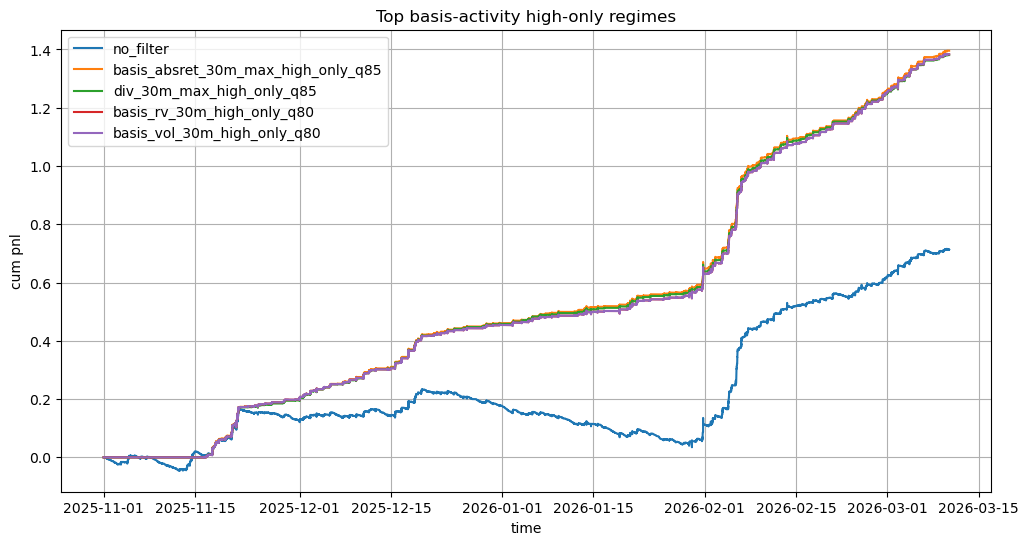

In [26]:
top_names = best_by_signal["name"].head(4).tolist()

plot_dict = {"no_filter": bt_no}
for n in top_names:
    plot_dict[n] = bt_store[n]

plot_cum_pnl(
    plot_dict,
    pnl_col="net_pnl",
    title="Top basis-activity high-only regimes"
)

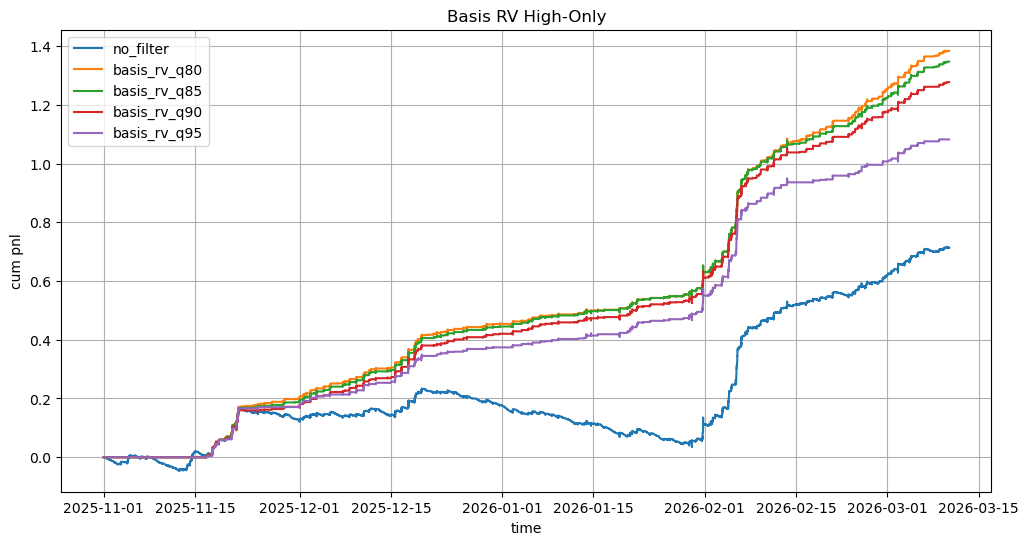

In [27]:
plot_cum_pnl(
    {
        "no_filter": bt_no,
        "basis_rv_q80": bt_store["basis_rv_30m_high_only_q80"],
        "basis_rv_q85": bt_store["basis_rv_30m_high_only_q85"],
        "basis_rv_q90": bt_store["basis_rv_30m_high_only_q90"],
        "basis_rv_q95": bt_store["basis_rv_30m_high_only_q95"],
    },
    pnl_col="net_pnl",
    title="Basis RV High-Only"
)

## Cost sensitivity

We now test whether the apparent advantage survives under higher transaction cost assumptions.

In [28]:
def run_cost_sensitivity(
    df: pd.DataFrame,
    cost_list=(2.0, 5.0, 10.0),
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
):
    rows = []
    bt_store = {}

    for cost in cost_list:
        bt_base = run_basis_zscore_strategy(
            df=df,
            basis_lookback_min=basis_lookback_min,
            freq_min=freq_min,
            entry_z=entry_z,
            exit_z=exit_z,
            cost_bps=cost,
            vol_filter_col=None,
        )
        bt_store[f"no_filter_cost{int(cost)}"] = bt_base
        row = summarize_backtest(bt_base, freq_min=freq_min).to_dict()
        row["strategy"] = "no_filter"
        row["cost_bps"] = cost
        rows.append(row)

        for sig, q in [("basis_vol_30m", 0.80), ("basis_rv_30m", 0.80)]:
            bt = run_basis_zscore_strategy(
                df=df,
                basis_lookback_min=basis_lookback_min,
                freq_min=freq_min,
                entry_z=entry_z,
                exit_z=exit_z,
                cost_bps=cost,
                vol_filter_col=sig,
                vol_filter_quantile=q,
                vol_filter_lookback_min=30 * 24 * 60,
                high_vol_only=True,
            )
            key = f"{sig.replace('_30m','')}_q80_cost{int(cost)}"
            bt_store[key] = bt

            row = summarize_backtest(bt, freq_min=freq_min).to_dict()
            row["strategy"] = key.replace(f"_cost{int(cost)}", "")
            row["cost_bps"] = cost
            rows.append(row)

    return pd.DataFrame(rows), bt_store

In [29]:
summary_cost, bt_cost_store = run_cost_sensitivity(
    df_all,
    cost_list=(2.0, 5.0, 10.0),
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
)

summary_cost

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,strategy,cost_bps
0,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0,no_filter,2.0
1,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_vol_q80,2.0
2,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_rv_q80,2.0
3,-7.310760,0.247423,-29.547665,-2.566973,2.900027,-2.566973,184550.0,5467.0,no_filter,5.0
4,1.460762,0.227621,6.417530,0.512906,1.963906,-0.107137,184550.0,1451.0,basis_vol_q80,5.0
5,1.460762,0.227621,6.417530,0.512906,1.963906,-0.107137,184550.0,1451.0,basis_rv_q80,5.0
6,-22.880824,0.283094,-80.824065,-8.033973,2.900027,-8.033973,184550.0,5467.0,no_filter,10.0
7,-2.671699,0.236368,-11.303125,-0.938094,1.963906,-0.938094,184550.0,1451.0,basis_vol_q80,10.0
8,-2.671699,0.236368,-11.303125,-0.938094,1.963906,-0.938094,184550.0,1451.0,basis_rv_q80,10.0


In [30]:
summary_cost.pivot(index="cost_bps", columns="strategy", values="sharpe")

strategy,basis_rv_q80,basis_vol_q80,no_filter
cost_bps,,,
2.0,17.391786,17.391786,8.515994
5.0,6.417530,6.417530,-29.547665
10.0,-11.303125,-11.303125,-80.824065


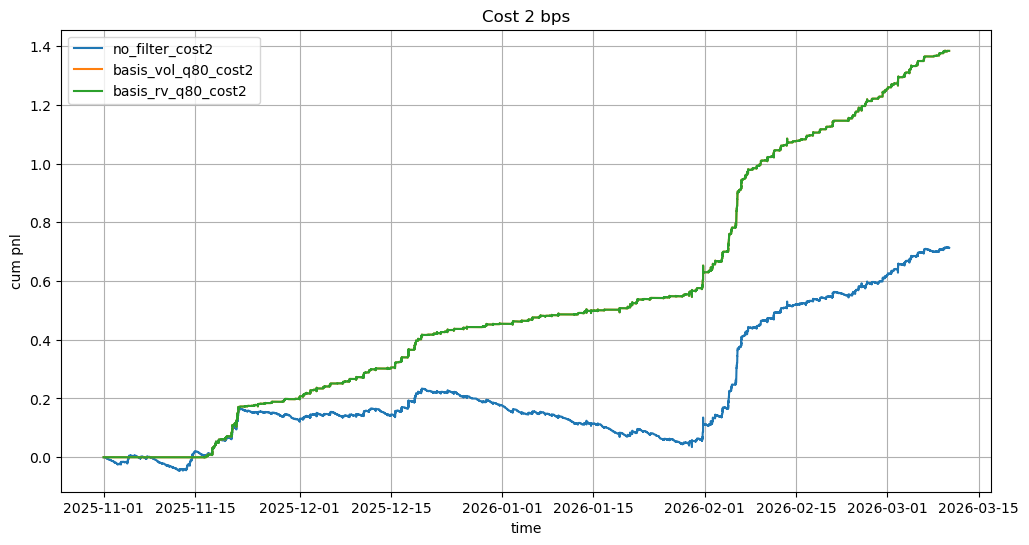

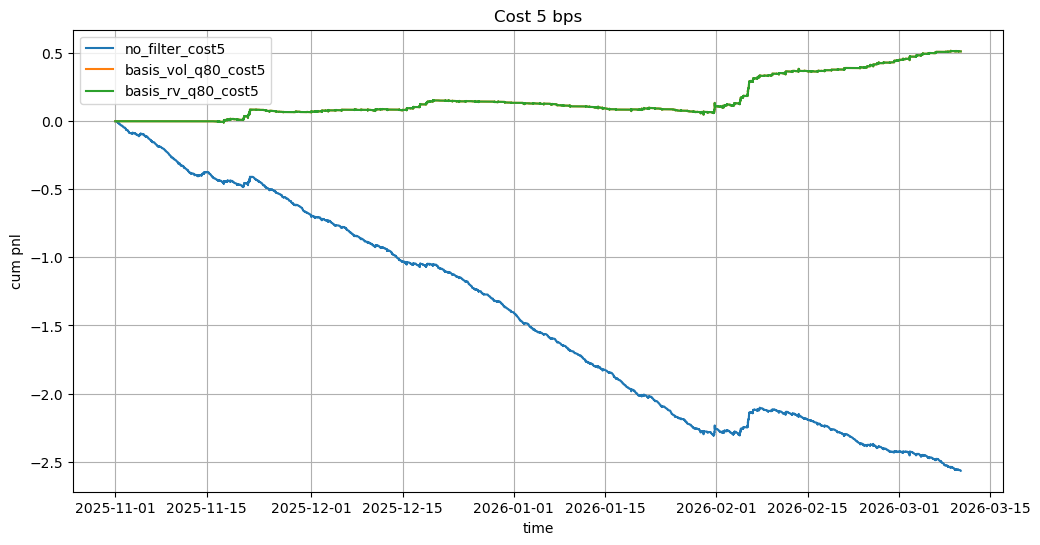

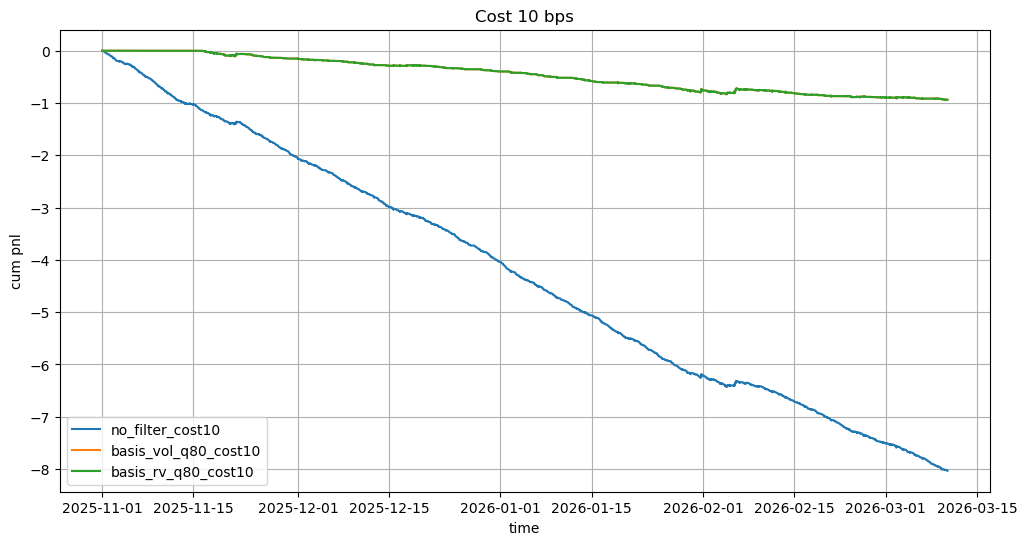

In [31]:
plot_cum_pnl(
    {
        "no_filter_cost2": bt_cost_store["no_filter_cost2"],
        "basis_vol_q80_cost2": bt_cost_store["basis_vol_q80_cost2"],
        "basis_rv_q80_cost2": bt_cost_store["basis_rv_q80_cost2"],
    },
    title="Cost 2 bps"
)

plot_cum_pnl(
    {
        "no_filter_cost5": bt_cost_store["no_filter_cost5"],
        "basis_vol_q80_cost5": bt_cost_store["basis_vol_q80_cost5"],
        "basis_rv_q80_cost5": bt_cost_store["basis_rv_q80_cost5"],
    },
    title="Cost 5 bps"
)

plot_cum_pnl(
    {
        "no_filter_cost10": bt_cost_store["no_filter_cost10"],
        "basis_vol_q80_cost10": bt_cost_store["basis_vol_q80_cost10"],
        "basis_rv_q80_cost10": bt_cost_store["basis_rv_q80_cost10"],
    },
    title="Cost 10 bps"
)

## Entry / exit sensitivity

We now check whether the stronger regimes pair better with more aggressive or more selective thresholds.

In [32]:
def run_entry_exit_sensitivity(
    df: pd.DataFrame,
    entry_list=(1.5, 2.0, 2.5),
    exit_list=(0.25, 0.5, 1.0),
    cost_bps=2.0,
    basis_lookback_min=240,
    freq_min=1,
):
    rows = []
    bt_store = {}

    for entry_z in entry_list:
        for exit_z in exit_list:
            bt_base = run_basis_zscore_strategy(
                df=df,
                basis_lookback_min=basis_lookback_min,
                freq_min=freq_min,
                entry_z=entry_z,
                exit_z=exit_z,
                cost_bps=cost_bps,
                vol_filter_col=None,
            )
            name_base = f"baseline_e{entry_z}_x{exit_z}"
            bt_store[name_base] = bt_base
            row = summarize_backtest(bt_base, freq_min=freq_min).to_dict()
            row.update({"strategy": "baseline", "entry_z": entry_z, "exit_z": exit_z})
            rows.append(row)

            for sig in ["basis_vol_30m", "basis_rv_30m"]:
                bt = run_basis_zscore_strategy(
                    df=df,
                    basis_lookback_min=basis_lookback_min,
                    freq_min=freq_min,
                    entry_z=entry_z,
                    exit_z=exit_z,
                    cost_bps=cost_bps,
                    vol_filter_col=sig,
                    vol_filter_quantile=0.80,
                    vol_filter_lookback_min=30 * 24 * 60,
                    high_vol_only=True,
                )
                name = f"{sig}_q80_e{entry_z}_x{exit_z}"
                bt_store[name] = bt

                row = summarize_backtest(bt, freq_min=freq_min).to_dict()
                row.update({"strategy": sig, "entry_z": entry_z, "exit_z": exit_z})
                rows.append(row)

    return pd.DataFrame(rows), bt_store

In [33]:
summary_ex, bt_ex_store = run_entry_exit_sensitivity(
    df_all,
    entry_list=(1.5, 2.0, 2.5),
    exit_list=(0.25, 0.5, 1.0),
    cost_bps=2.0,
    basis_lookback_min=240,
    freq_min=1,
)

summary_ex

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,strategy,entry_z,exit_z
0,-0.737178,0.258909,-2.847252,-0.258840,3.021560,-0.682443,184550.0,8201.0,baseline,1.5,0.25
1,3.530791,0.243955,14.473100,1.239740,1.917340,-0.025467,184550.0,1694.0,basis_vol_30m,1.5,0.25
2,3.530791,0.243955,14.473100,1.239740,1.917340,-0.025467,184550.0,1694.0,basis_rv_30m,1.5,0.25
3,-1.178337,0.249490,-4.722989,-0.413741,3.611459,-0.929761,184550.0,10063.0,baseline,1.5,0.50
4,4.132635,0.235156,17.573978,1.451061,2.244661,-0.026506,184550.0,1984.0,basis_vol_30m,1.5,0.50
5,4.132635,0.235156,17.573978,1.451061,2.244661,-0.026506,184550.0,1984.0,basis_rv_30m,1.5,0.50
6,-2.017850,0.239239,-8.434440,-0.708513,4.087887,-1.260158,184550.0,11991.0,baseline,1.5,1.00
7,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,basis_vol_30m,1.5,1.00
8,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,basis_rv_30m,1.5,1.00
9,1.775259,0.248845,7.133982,0.623333,2.532133,-0.166889,184550.0,4772.0,baseline,2.0,0.25


In [34]:
summary_ex.pivot_table(
    index=["entry_z", "exit_z"],
    columns="strategy",
    values="sharpe"
)

strategy         baseline  basis_rv_30m  basis_vol_30m
entry_z exit_z                                        
1.5     0.25    -2.847252     14.473100      14.473100
        0.50    -4.722989     17.573978      17.573978
        1.00    -8.434440     20.800271      20.800271
2.0     0.25     7.133982     14.614125      14.614125
        0.50     8.515994     17.391786      17.391786
        1.00     9.481180     20.399760      20.399760
2.5     0.25    11.413431     14.357676      14.357676
        0.50    13.730475     16.866356      16.866356
        1.00    16.158360     19.746814      19.746814

In [35]:
summary_ex.pivot_table(
    index=["entry_z", "exit_z"],
    columns="strategy",
    values="n_trade_opens"
)

strategy        baseline  basis_rv_30m  basis_vol_30m
entry_z exit_z                                       
1.5     0.25      8201.0        1694.0         1694.0
        0.50     10063.0        1984.0         1984.0
        1.00     11991.0        2267.0         2267.0
2.0     0.25      4772.0        1272.0         1272.0
        0.50      5467.0        1451.0         1451.0
        1.00      6163.0        1636.0         1636.0
2.5     0.25      2893.0        1020.0         1020.0
        0.50      3196.0        1148.0         1148.0
        1.00      3493.0        1285.0         1285.0

## Lookback sensitivity

We check whether a shorter or longer basis z-score lookback is better.

In [36]:
def run_lookback_sensitivity(
    df: pd.DataFrame,
    lookback_list=(120, 240, 360, 720),
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    freq_min=1,
):
    rows = []
    bt_store = {}

    for lookback in lookback_list:
        bt_base = run_basis_zscore_strategy(
            df=df,
            basis_lookback_min=lookback,
            freq_min=freq_min,
            entry_z=entry_z,
            exit_z=exit_z,
            cost_bps=cost_bps,
            vol_filter_col=None,
        )
        bt_store[f"baseline_lb{lookback}"] = bt_base
        row = summarize_backtest(bt_base, freq_min=freq_min).to_dict()
        row.update({"strategy": "baseline", "basis_lookback_min": lookback})
        rows.append(row)

        for sig in ["basis_vol_30m", "basis_rv_30m"]:
            bt = run_basis_zscore_strategy(
                df=df,
                basis_lookback_min=lookback,
                freq_min=freq_min,
                entry_z=entry_z,
                exit_z=exit_z,
                cost_bps=cost_bps,
                vol_filter_col=sig,
                vol_filter_quantile=0.80,
                vol_filter_lookback_min=30 * 24 * 60,
                high_vol_only=True,
            )
            bt_store[f"{sig}_lb{lookback}"] = bt
            row = summarize_backtest(bt, freq_min=freq_min).to_dict()
            row.update({"strategy": sig, "basis_lookback_min": lookback})
            rows.append(row)

    return pd.DataFrame(rows), bt_store

In [37]:
summary_lb_cons, bt_lb_cons = run_lookback_sensitivity(
    df_all,
    lookback_list=(120, 240, 360, 720),
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    freq_min=1,
)

summary_lb_cons

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,strategy,basis_lookback_min
0,1.286154,0.232682,5.527505,0.451597,3.022797,-0.254463,184550.0,6428.0,baseline,120
1,3.958740,0.219484,18.036559,1.390003,1.962003,-0.023772,184550.0,1430.0,basis_vol_30m,120
2,3.958740,0.219484,18.036559,1.390003,1.962003,-0.023772,184550.0,1430.0,basis_rv_30m,120
3,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0,baseline,240
4,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_vol_30m,240
5,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_rv_30m,240
6,2.456726,0.243774,10.077865,0.862612,2.827812,-0.161682,184550.0,4913.0,baseline,360
7,3.992963,0.232550,17.170364,1.402019,2.006419,-0.023755,184550.0,1511.0,basis_vol_30m,360
8,3.992963,0.232550,17.170364,1.402019,2.006419,-0.023755,184550.0,1511.0,basis_rv_30m,360
9,3.234163,0.251836,12.842360,1.135588,2.670388,-0.078171,184550.0,3837.0,baseline,720


In [38]:
summary_lb_cons.pivot_table(
    index="basis_lookback_min",
    columns="strategy",
    values="sharpe"
)

strategy,baseline,basis_rv_30m,basis_vol_30m
basis_lookback_min,,,
120,5.527505,18.036559,18.036559
240,8.515994,17.391786,17.391786
360,10.077865,17.170364,17.170364
720,12.842360,16.726334,16.726334


In [39]:
summary_lb_aggr, bt_lb_aggr = run_lookback_sensitivity(
    df_all,
    lookback_list=(120, 240, 360, 720),
    entry_z=1.5,
    exit_z=1.0,
    cost_bps=2.0,
    freq_min=1,
)

summary_lb_aggr

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,strategy,basis_lookback_min
0,-3.825487,0.234635,-16.303983,-1.343215,4.242185,-1.644727,184550.0,13964.0,baseline,120
1,4.571182,0.219861,20.791220,1.605045,2.473845,-0.025908,184550.0,2172.0,basis_vol_30m,120
2,4.571182,0.219861,20.791220,1.605045,2.473845,-0.025908,184550.0,2172.0,basis_rv_30m,120
3,-2.017850,0.239239,-8.434440,-0.708513,4.087887,-1.260158,184550.0,11991.0,baseline,240
4,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,basis_vol_30m,240
5,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,basis_rv_30m,240
6,-1.090439,0.243331,-4.481302,-0.382878,3.902322,-1.020131,184550.0,10713.0,baseline,360
7,4.582570,0.230746,19.859764,1.609044,2.532644,-0.026404,184550.0,2309.0,basis_vol_30m,360
8,4.582570,0.230746,19.859764,1.609044,2.532644,-0.026404,184550.0,2309.0,basis_rv_30m,360
9,1.102656,0.249496,4.419536,0.387167,3.613967,-0.548283,184550.0,8067.0,baseline,720


In [40]:
summary_lb_aggr.pivot_table(
    index="basis_lookback_min",
    columns="strategy",
    values="sharpe"
)

strategy,baseline,basis_rv_30m,basis_vol_30m
basis_lookback_min,,,
120,-16.303983,20.791220,20.791220
240,-8.434440,20.800271,20.800271
360,-4.481302,19.859764,19.859764
720,4.419536,19.232852,19.232852


## Main and conservative versions

The notebook now defines:

- a stronger **main** version
- a more selective **conservative** version
- the original baseline

In [42]:
# 主版本参数：
# basis_rv_30m_high_only_q80
# entry_z = 1.5
# exit_z = 1.0
# basis_lookback = 240
# cost_bps = 2.0

# 对照第二版本（conservative）
# basis_vol_30m_high_only_q80
# entry_z = 2.0
# exit_z = 0.5
# basis_lookback = 240
# cost_bps = 2.0

bt_main = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=1.5,
    exit_z=1.0,
    cost_bps=2.0,
    vol_filter_col="basis_rv_30m",
    vol_filter_quantile=0.80,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_conservative = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.80,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_baseline = bt_no.copy()

pd.DataFrame({
    "baseline": summarize_backtest(bt_baseline, freq_min=1),
    "main": summarize_backtest(bt_main, freq_min=1),
    "conservative": summarize_backtest(bt_conservative, freq_min=1),
}).T

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens
baseline,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0
main,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0
conservative,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0


## Monthly performance check

We check whether the improvement is broad-based across months or dominated by only one period.

In [44]:
def summarize_by_month(bt: pd.DataFrame) -> pd.DataFrame:
    x = bt.copy()
    x["month"] = pd.to_datetime(x["timestamp"], utc=True).dt.to_period("M").astype(str)

    rows = []
    for month, g in x.groupby("month"):
        r = g["net_pnl"].fillna(0.0)
        mean_r = r.mean()
        std_r = r.std()

        periods_per_year = 365 * 24 * 60
        ann_return = mean_r * periods_per_year
        ann_vol = std_r * np.sqrt(periods_per_year) if std_r > 0 else np.nan
        sharpe = ann_return / ann_vol if ann_vol and ann_vol > 0 else np.nan

        rows.append({
            "month": month,
            "ann_return": ann_return,
            "ann_vol": ann_vol,
            "sharpe": sharpe,
            "cum_net_pnl": r.cumsum().iloc[-1],
            "n_bars": len(g),
        })
    return pd.DataFrame(rows).sort_values("month")


month_baseline = summarize_by_month(bt_baseline)
month_main = summarize_by_month(bt_main)
month_conservative = summarize_by_month(bt_conservative)

print("BASELINE")
print(month_baseline)

print("\nMAIN")
print(month_main)

print("\nCONSERVATIVE")
print(month_conservative)

/var/folders/hf/yshrdhps6xn3rb_hk1nww00m0000gn/T/ipykernel_64705/1280302865.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  x["month"] = pd.to_datetime(x["timestamp"], utc=True).dt.to_period("M").astype(str)
/var/folders/hf/yshrdhps6xn3rb_hk1nww00m0000gn/T/ipykernel_64705/1280302865.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  x["month"] = pd.to_datetime(x["timestamp"], utc=True).dt.to_period("M").astype(str)
/var/folders/hf/yshrdhps6xn3rb_hk1nww00m0000gn/T/ipykernel_64705/1280302865.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  x["month"] = pd.to_datetime(x["timestamp"], utc=True).dt.to_period("M").astype(str)


BASELINE
     month  ann_return   ann_vol     sharpe  cum_net_pnl  n_bars
0  2025-11    1.498401  0.202625   7.394945     0.123153   43199
1  2025-12    0.645384  0.191513   3.369920     0.053788   43805
2  2026-01   -0.773434  0.234038  -3.304731    -0.065150   44274
3  2026-02    6.744142  0.315581  21.370551     0.508877   39659
4  2026-03    3.573712  0.233536  15.302587     0.092559   13613

MAIN
     month  ann_return   ann_vol     sharpe  cum_net_pnl  n_bars
0  2025-11    2.626254  0.164945  15.921975     0.215851   43199
1  2025-12    3.745378  0.180341  20.768359     0.312150   43805
2  2026-01    1.880213  0.230818   8.145877     0.158380   44274
3  2026-02   10.697058  0.308169  34.711625     0.807144   39659
4  2026-03    5.972286  0.221895  26.914952     0.154682   13613

CONSERVATIVE
     month  ann_return   ann_vol     sharpe  cum_net_pnl  n_bars
0  2025-11    2.420003  0.161897  14.947820     0.198900   43199
1  2025-12    3.067221  0.186594  16.437929     0.255631   43

In [45]:
month_compare = (
    month_baseline[["month", "cum_net_pnl", "sharpe"]]
    .rename(columns={"cum_net_pnl": "baseline_cum_pnl", "sharpe": "baseline_sharpe"})
    .merge(
        month_main[["month", "cum_net_pnl", "sharpe"]]
        .rename(columns={"cum_net_pnl": "main_cum_pnl", "sharpe": "main_sharpe"}),
        on="month",
        how="outer",
    )
    .merge(
        month_conservative[["month", "cum_net_pnl", "sharpe"]]
        .rename(columns={"cum_net_pnl": "cons_cum_pnl", "sharpe": "cons_sharpe"}),
        on="month",
        how="outer",
    )
    .sort_values("month")
)

month_compare

,month,baseline_cum_pnl,baseline_sharpe,main_cum_pnl,main_sharpe,cons_cum_pnl,cons_sharpe
0,2025-11,0.123153,7.394945,0.215851,15.921975,0.198900,14.947820
1,2025-12,0.053788,3.369920,0.312150,20.768359,0.255631,16.437929
2,2026-01,-0.065150,-3.304731,0.158380,8.145877,0.174751,8.965679
3,2026-02,0.508877,21.370551,0.807144,34.711625,0.625178,26.845199
4,2026-03,0.092559,15.302587,0.154682,26.914952,0.129047,22.541790


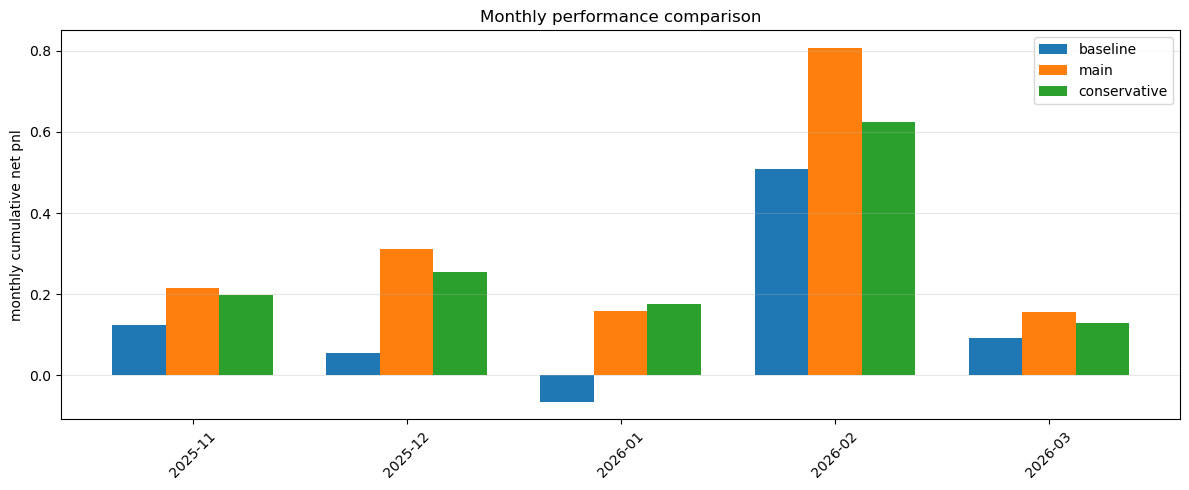

In [46]:
def plot_monthly_cum_pnl_compare(month_compare: pd.DataFrame):
    x = np.arange(len(month_compare))
    w = 0.25

    plt.figure(figsize=(12, 5))
    plt.bar(x - w, month_compare["baseline_cum_pnl"], width=w, label="baseline")
    plt.bar(x, month_compare["main_cum_pnl"], width=w, label="main")
    plt.bar(x + w, month_compare["cons_cum_pnl"], width=w, label="conservative")
    plt.xticks(x, month_compare["month"], rotation=45)
    plt.ylabel("monthly cumulative net pnl")
    plt.title("Monthly performance comparison")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_monthly_cum_pnl_compare(month_compare)

## More realistic trading constraints

We now add more realistic constraints in stages:

1. max holding period
2. fixed position sizing from capital
3. next-bar execution
4. fee + slippage assumptions

In [48]:
def run_basis_zscore_strategy_with_max_hold(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    vol_filter_col: Optional[str] = None,
    vol_filter_quantile: float = 0.80,
    vol_filter_lookback_min: int = 30 * 24 * 60,
    high_vol_only: bool = False,
    max_holding_min: Optional[int] = 120,
) -> pd.DataFrame:
    out = (
        df.copy()
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"], keep="last")
          .reset_index(drop=True)
    )

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    if vol_filter_col is not None:
        VW = int(round(vol_filter_lookback_min / freq_min))
        out["vol_filter_threshold"] = (
            out[vol_filter_col]
            .rolling(VW, min_periods=max(100, int(0.5 * VW)))
            .quantile(vol_filter_quantile)
            .shift(1)
        )
    else:
        out["vol_filter_threshold"] = np.nan

    pos = np.zeros(len(out), dtype=float)
    hold_bars = 0
    max_holding_bars = None if max_holding_min is None else int(round(max_holding_min / freq_min))

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            if prev_pos != 0:
                hold_bars += 1
            continue

        if prev_pos != 0:
            hold_bars += 1

        force_exit = False
        if max_holding_bars is not None and prev_pos != 0 and hold_bars >= max_holding_bars:
            force_exit = True

        if force_exit:
            prev_pos = 0
            hold_bars = 0
        else:
            if prev_pos == 1 and abs(z) < exit_z:
                prev_pos = 0
                hold_bars = 0
            elif prev_pos == -1 and abs(z) < exit_z:
                prev_pos = 0
                hold_bars = 0

        if prev_pos == 0:
            allow_entry = True
            if vol_filter_col is not None:
                thr = out.at[i, "vol_filter_threshold"]
                sig = out.at[i, vol_filter_col]
                if pd.isna(thr) or pd.isna(sig):
                    allow_entry = False
                else:
                    allow_entry = bool(sig >= thr) if high_vol_only else bool(sig <= thr)

            if allow_entry:
                if z > entry_z:
                    prev_pos = -1
                    hold_bars = 0
                elif z < -entry_z:
                    prev_pos = 1
                    hold_bars = 0

        pos[i] = prev_pos

    out["position"] = pos
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out


def run_max_hold_sensitivity_main(df: pd.DataFrame):
    rows = []
    bt_store = {}

    holds = [30, 60, 120, 240, None]

    for h in holds:
        label = "none" if h is None else str(h)

        bt = run_basis_zscore_strategy_with_max_hold(
            df=df,
            basis_lookback_min=240,
            freq_min=1,
            entry_z=1.5,
            exit_z=1.0,
            cost_bps=2.0,
            vol_filter_col="basis_rv_30m",
            vol_filter_quantile=0.80,
            vol_filter_lookback_min=30 * 24 * 60,
            high_vol_only=True,
            max_holding_min=h,
        )
        bt_store[f"main_hold_{label}"] = bt

        row = summarize_backtest(bt, freq_min=1).to_dict()
        row["max_holding_min"] = h
        rows.append(row)

    return pd.DataFrame(rows), bt_store


summary_hold, bt_hold_store = run_max_hold_sensitivity_main(df_all)
summary_hold

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,max_holding_min
0,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,30.0
1,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,60.0
2,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,120.0
3,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,240.0
4,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,NaN


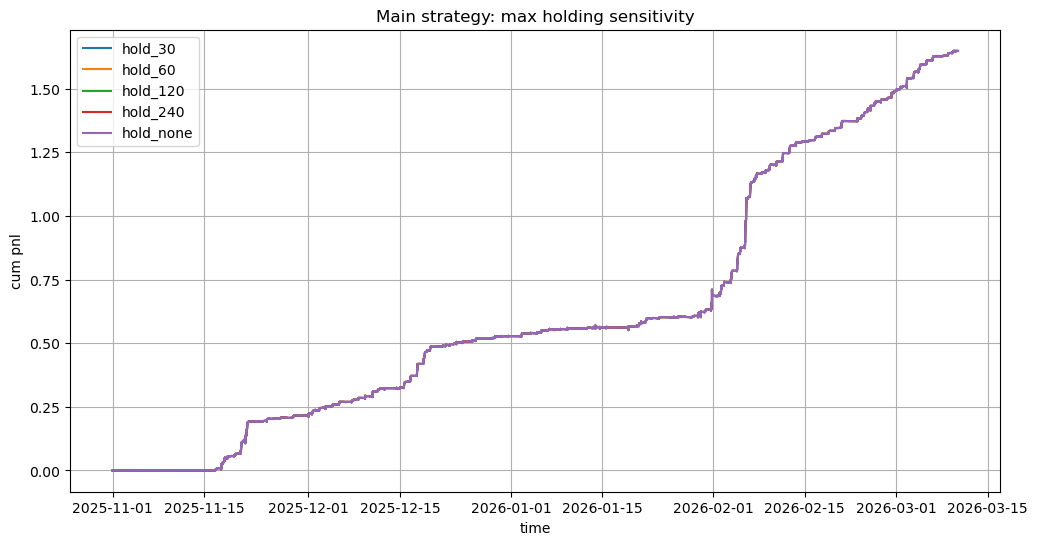

In [49]:
plot_cum_pnl(
    {
        "hold_30": bt_hold_store["main_hold_30"],
        "hold_60": bt_hold_store["main_hold_60"],
        "hold_120": bt_hold_store["main_hold_120"],
        "hold_240": bt_hold_store["main_hold_240"],
        "hold_none": bt_hold_store["main_hold_none"],
    },
    title="Main strategy: max holding sensitivity"
)

In [54]:
def z_to_size_multiplier(abs_z: float, entry_z: float) -> float:
    if np.isnan(abs_z) or abs_z < entry_z:
        return 0.0
    elif abs_z < entry_z + 0.5:
        return 0.50
    elif abs_z < entry_z + 1.0:
        return 0.75
    else:
        return 1.00


def run_level1_backtest(
    df: pd.DataFrame,
    initial_capital: float = 100000.0,
    max_position_fraction: float = 0.10,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 1.5,
    exit_z: float = 1.0,
    max_holding_min: int | None = 120,
    regime_signal_col: str | None = "basis_rv_30m",
    regime_quantile: float = 0.80,
    regime_lookback_min: int = 30 * 24 * 60,
    fee_bps: float = 2.5,
    slippage_bps: float = 2.5,
):
    out = df.copy().sort_values("timestamp").reset_index(drop=True)

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    if regime_signal_col is not None:
        VW = int(round(regime_lookback_min / freq_min))
        out["regime_threshold"] = (
            out[regime_signal_col]
            .rolling(VW, min_periods=max(100, int(0.5 * VW)))
            .quantile(regime_quantile)
            .shift(1)
        )
        out["allow_entry"] = (out[regime_signal_col] >= out["regime_threshold"]).astype(float)
        out.loc[out["regime_threshold"].isna(), "allow_entry"] = 0.0
    else:
        out["allow_entry"] = 1.0

    max_holding_bars = None if max_holding_min is None else int(round(max_holding_min / freq_min))

    position_dir = np.zeros(len(out), dtype=float)
    hold_bars = 0

    for i in range(1, len(out)):
        prev = position_dir[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            position_dir[i] = prev
            if prev != 0:
                hold_bars += 1
            continue

        if prev != 0:
            hold_bars += 1

        if max_holding_bars is not None and prev != 0 and hold_bars >= max_holding_bars:
            prev = 0
            hold_bars = 0
        else:
            if prev == 1 and abs(z) < exit_z:
                prev = 0
                hold_bars = 0
            elif prev == -1 and abs(z) < exit_z:
                prev = 0
                hold_bars = 0

        if prev == 0 and bool(out.at[i, "allow_entry"]):
            if z > entry_z:
                prev = -1
                hold_bars = 0
            elif z < -entry_z:
                prev = 1
                hold_bars = 0

        position_dir[i] = prev

    out["position_dir"] = position_dir
    out["z_size_multiplier"] = out["basis_z"].abs().apply(lambda z: z_to_size_multiplier(z, entry_z=entry_z))

    out["notional"] = initial_capital * max_position_fraction * out["z_size_multiplier"]
    out["gross_pnl_dollars"] = out["position_dir"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0) * out["notional"].shift(1).fillna(0.0)

    turn = np.abs(out["position_dir"].diff().fillna(out["position_dir"]))
    total_cost_bps = fee_bps + slippage_bps
    out["trade_cost_dollars"] = turn * (total_cost_bps / 1e4) * out["notional"]

    out["net_pnl_dollars"] = out["gross_pnl_dollars"] - out["trade_cost_dollars"]
    out["cum_pnl_dollars"] = out["net_pnl_dollars"].cumsum()

    out["nav"] = initial_capital + out["cum_pnl_dollars"]
    out["nav_ret"] = out["nav"].pct_change().fillna(0.0)
    out["cum_return"] = out["nav"] / initial_capital - 1.0

    return out


def summarize_level1(bt: pd.DataFrame, freq_min: int = 1) -> pd.Series:
    r = bt["nav_ret"].fillna(0.0)
    periods_per_year = 365 * 24 * (60 // freq_min)

    ann_return = r.mean() * periods_per_year
    ann_vol = r.std() * np.sqrt(periods_per_year) if r.std() > 0 else np.nan
    sharpe = ann_return / ann_vol if ann_vol and ann_vol > 0 else np.nan

    cum_curve = bt["cum_pnl_dollars"].ffill().fillna(0.0)
    peak = cum_curve.cummax()
    dd = cum_curve - peak

    return pd.Series({
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "final_nav": bt["nav"].iloc[-1],
        "cum_return": bt["cum_return"].iloc[-1],
        "max_drawdown": dd.min(),
    })


initial_capital = 1000.0
bt_level1_main = run_level1_backtest(
    df_all,
    initial_capital=initial_capital,
    max_position_fraction=0.05,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=1.5,
    exit_z=1.0,
    max_holding_min=120,
    regime_signal_col="basis_rv_30m",
    regime_quantile=0.80,
    regime_lookback_min=30 * 24 * 60,
    fee_bps=2.5,
    slippage_bps=2.5,
)

summarize_level1(bt_level1_main, freq_min=1)

ann_return         0.184911
ann_vol            0.010461
sharpe            17.676787
final_nav       1067.060087
cum_return         0.067060
max_drawdown      -1.363512
dtype: float64

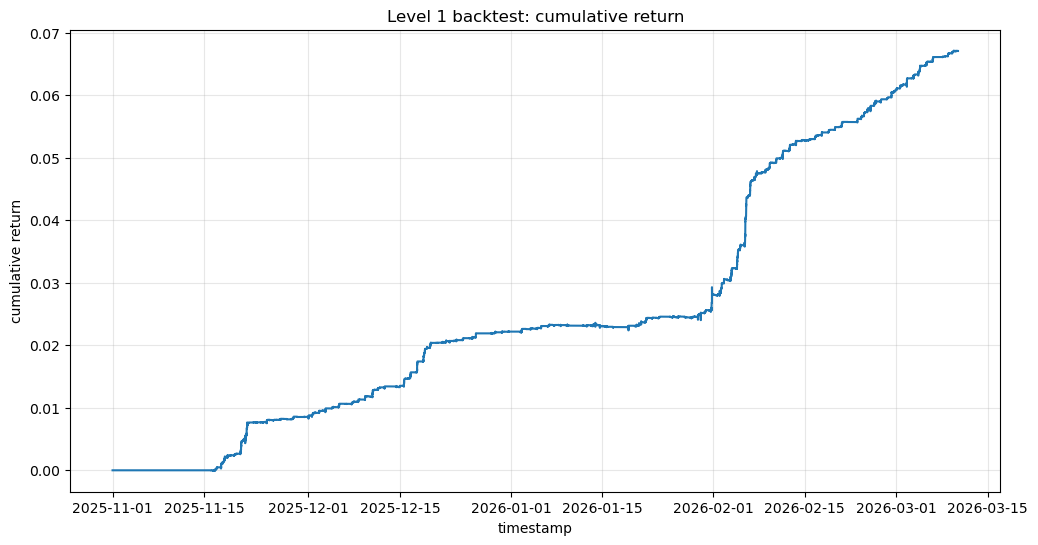

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(bt_level1_main["timestamp"], bt_level1_main["cum_return"])
plt.title("Level 1 backtest: cumulative return")
plt.xlabel("timestamp")
plt.ylabel("cumulative return")
plt.grid(True, alpha=0.3)
plt.show()

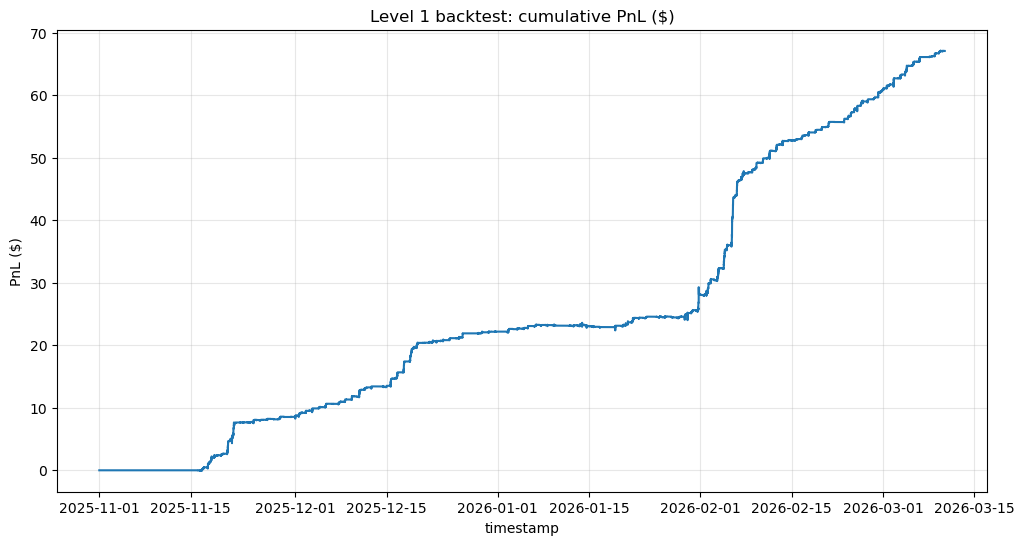

In [52]:
plt.figure(figsize=(12, 6))
plt.plot(bt_level1_main["timestamp"], bt_level1_main["nav"] - initial_capital)
plt.title("Level 1 backtest: cumulative PnL ($)")
plt.xlabel("timestamp")
plt.ylabel("PnL ($)")
plt.grid(True, alpha=0.3)
plt.show()

## Level-1 fee / slippage sensitivity

Now we hold the overall strategy structure fixed and vary explicit friction assumptions.

In [55]:
def run_level1_cost_sensitivity(
    df: pd.DataFrame,
    initial_capital: float = 1000.0,
    max_position_fraction: float = 0.05,
    cost_pairs=((0.5, 0.5), (1.0, 1.0), (2.5, 2.5), (5.0, 5.0), (10.0, 0.0)),
):
    rows = []
    bt_store = {}

    for fee_bps, slippage_bps in cost_pairs:
        label = f"fee{fee_bps}_slip{slippage_bps}"

        bt = run_level1_backtest(
            df,
            initial_capital=initial_capital,
            max_position_fraction=max_position_fraction,
            basis_lookback_min=240,
            freq_min=1,
            entry_z=1.5,
            exit_z=1.0,
            max_holding_min=120,
            regime_signal_col="basis_rv_30m",
            regime_quantile=0.80,
            regime_lookback_min=30 * 24 * 60,
            fee_bps=fee_bps,
            slippage_bps=slippage_bps,
        )
        bt_store[label] = bt

        row = summarize_level1(bt, freq_min=1).to_dict()
        row["fee_bps"] = fee_bps
        row["slippage_bps"] = slippage_bps
        row["total_cost_bps"] = fee_bps + slippage_bps
        rows.append(row)

    return pd.DataFrame(rows), bt_store


summary_l1_cost, bt_l1_cost = run_level1_cost_sensitivity(
    df_all,
    initial_capital=1000.0,
    max_position_fraction=0.05,
    cost_pairs=((0.5, 0.5), (1.0, 1.0), (2.5, 2.5), (5.0, 5.0), (10.0, 0.0)),
)

summary_l1_cost

,ann_return,ann_vol,sharpe,final_nav,cum_return,max_drawdown,fee_bps,slippage_bps,total_cost_bps
0,0.279137,0.010147,27.508632,1102.955087,0.102955,-1.155519,0.5,0.5,1.0
1,0.255871,0.010210,25.061083,1093.981337,0.093981,-1.160470,1.0,1.0,2.0
2,0.184911,0.010461,17.676787,1067.060087,0.067060,-1.363512,2.5,2.5,5.0
3,0.062572,0.011088,5.642964,1022.191337,0.022191,-8.956032,5.0,5.0,10.0
4,0.062572,0.011088,5.642964,1022.191337,0.022191,-8.956032,10.0,0.0,10.0


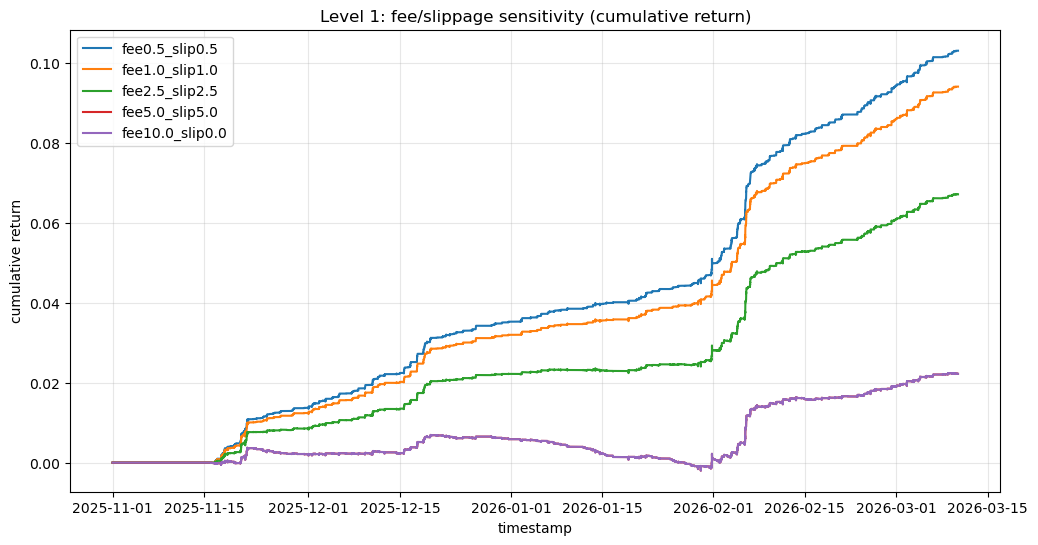

In [56]:
plt.figure(figsize=(12, 6))
for name, bt in bt_l1_cost.items():
    plt.plot(bt["timestamp"], bt["cum_return"], label=name)
plt.title("Level 1: fee/slippage sensitivity (cumulative return)")
plt.xlabel("timestamp")
plt.ylabel("cumulative return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

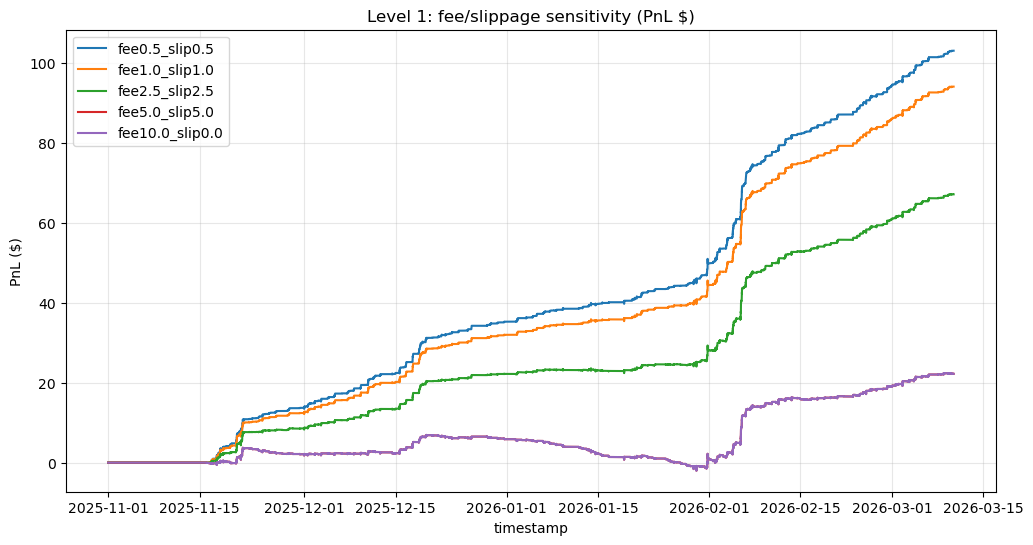

In [57]:
plt.figure(figsize=(12, 6))
for name, bt in bt_l1_cost.items():
    plt.plot(bt["timestamp"], bt["cum_pnl_dollars"], label=name)
plt.title("Level 1: fee/slippage sensitivity (PnL $)")
plt.xlabel("timestamp")
plt.ylabel("PnL ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Realistic-cost grid search

Because costs change the preferred parameter region, we now run a broader realistic-cost sweep.

In [58]:
def run_level1_grid_search(
    df: pd.DataFrame,
    initial_capital: float = 1000.0,
    max_position_fraction: float = 0.05,
    fee_bps: float = 2.5,
    slippage_bps: float = 2.5,
    regime_signals=("basis_rv_30m", "basis_vol_30m"),
    quantiles=(0.80, 0.85, 0.90, 0.95),
    entry_list=(1.5, 2.0, 2.5),
    exit_list=(0.5, 1.0),
    lookback_list=(120, 240, 360),
    max_holding_min: int = 120,
):
    rows = []
    bt_store = {}

    for regime_signal in regime_signals:
        for q in quantiles:
            for entry_z in entry_list:
                for exit_z in exit_list:
                    for lookback in lookback_list:
                        name = f"{regime_signal}_q{int(q*100)}_e{entry_z}_x{exit_z}_lb{lookback}"

                        bt = run_level1_backtest(
                            df,
                            initial_capital=initial_capital,
                            max_position_fraction=max_position_fraction,
                            basis_lookback_min=lookback,
                            freq_min=1,
                            entry_z=entry_z,
                            exit_z=exit_z,
                            max_holding_min=max_holding_min,
                            regime_signal_col=regime_signal,
                            regime_quantile=q,
                            regime_lookback_min=30 * 24 * 60,
                            fee_bps=fee_bps,
                            slippage_bps=slippage_bps,
                        )
                        bt_store[name] = bt

                        row = summarize_level1(bt, freq_min=1).to_dict()
                        row.update({
                            "name": name,
                            "regime_signal": regime_signal,
                            "quantile": q,
                            "entry_z": entry_z,
                            "exit_z": exit_z,
                            "basis_lookback_min": lookback,
                        })
                        rows.append(row)

    out = pd.DataFrame(rows).sort_values("sharpe", ascending=False).reset_index(drop=True)
    return out, bt_store


summary_realistic, bt_realistic_store = run_level1_grid_search(
    df_all,
    initial_capital=1000.0,
    max_position_fraction=0.05,
    fee_bps=5.0,
    slippage_bps=2.5,
    regime_signals=("basis_rv_30m", "basis_vol_30m"),
    quantiles=(0.80, 0.85, 0.90, 0.95),
    entry_list=(1.5, 2.0, 2.5),
    exit_list=(0.5, 1.0),
    lookback_list=(120, 240, 360),
    max_holding_min=120,
)

summary_realistic.head(10)

,ann_return,ann_vol,sharpe,final_nav,cum_return,max_drawdown,name,regime_signal,quantile,entry_z,exit_z,basis_lookback_min
0,0.145569,0.009903,14.700042,1052.423165,0.052423,-1.281763,basis_vol_30m_q90_e1.5_x1.0_lb120,basis_vol_30m,0.90,1.5,1.0,120
1,0.145569,0.009903,14.700042,1052.423165,0.052423,-1.281763,basis_rv_30m_q90_e1.5_x1.0_lb120,basis_rv_30m,0.90,1.5,1.0,120
2,0.137889,0.009410,14.653424,1049.590780,0.049591,-1.093820,basis_vol_30m_q90_e2.0_x1.0_lb120,basis_vol_30m,0.90,2.0,1.0,120
3,0.137889,0.009410,14.653424,1049.590780,0.049591,-1.093820,basis_rv_30m_q90_e2.0_x1.0_lb120,basis_rv_30m,0.90,2.0,1.0,120
4,0.130968,0.008960,14.617633,1047.044627,0.047045,-1.223394,basis_rv_30m_q95_e1.5_x1.0_lb120,basis_rv_30m,0.95,1.5,1.0,120
5,0.130968,0.008960,14.617633,1047.044627,0.047045,-1.223394,basis_vol_30m_q95_e1.5_x1.0_lb120,basis_vol_30m,0.95,1.5,1.0,120
6,0.141547,0.009810,14.428607,1050.938364,0.050938,-1.226951,basis_vol_30m_q90_e2.0_x1.0_lb240,basis_vol_30m,0.90,2.0,1.0,240
7,0.141547,0.009810,14.428607,1050.938364,0.050938,-1.226951,basis_rv_30m_q90_e2.0_x1.0_lb240,basis_rv_30m,0.90,2.0,1.0,240
8,0.145011,0.010104,14.352221,1052.216310,0.052216,-1.233913,basis_rv_30m_q90_e2.0_x1.0_lb360,basis_rv_30m,0.90,2.0,1.0,360
9,0.145011,0.010104,14.352221,1052.216310,0.052216,-1.233913,basis_vol_30m_q90_e2.0_x1.0_lb360,basis_vol_30m,0.90,2.0,1.0,360


In [59]:
best_by_signal = (
    summary_realistic
    .sort_values("sharpe", ascending=False)
    .groupby("regime_signal", as_index=False)
    .first()
    .sort_values("sharpe", ascending=False)
)

best_by_signal

,regime_signal,ann_return,ann_vol,sharpe,final_nav,cum_return,max_drawdown,name,quantile,entry_z,exit_z,basis_lookback_min
0,basis_rv_30m,0.145569,0.009903,14.700042,1052.423165,0.052423,-1.281763,basis_rv_30m_q90_e1.5_x1.0_lb120,0.9,1.5,1.0,120
1,basis_vol_30m,0.145569,0.009903,14.700042,1052.423165,0.052423,-1.281763,basis_vol_30m_q90_e1.5_x1.0_lb120,0.9,1.5,1.0,120


In [60]:
summary_realistic.groupby(["regime_signal", "quantile"])["sharpe"].mean().unstack()

quantile,0.80,0.85,0.90,0.95
regime_signal,,,,
basis_rv_30m,11.799664,12.518531,13.286576,12.839877
basis_vol_30m,11.799664,12.518531,13.286576,12.839877


In [61]:
summary_realistic.groupby(["entry_z", "exit_z"])["sharpe"].mean().unstack()

exit_z,0.5,1.0
entry_z,,
1.5,11.526522,13.152059
2.0,11.764295,13.844751
2.5,11.734583,13.644762


In [62]:
summary_realistic.groupby("basis_lookback_min")["sharpe"].mean()

basis_lookback_min
120    12.929970
240    12.467128
360    12.436387
Name: sharpe, dtype: float64

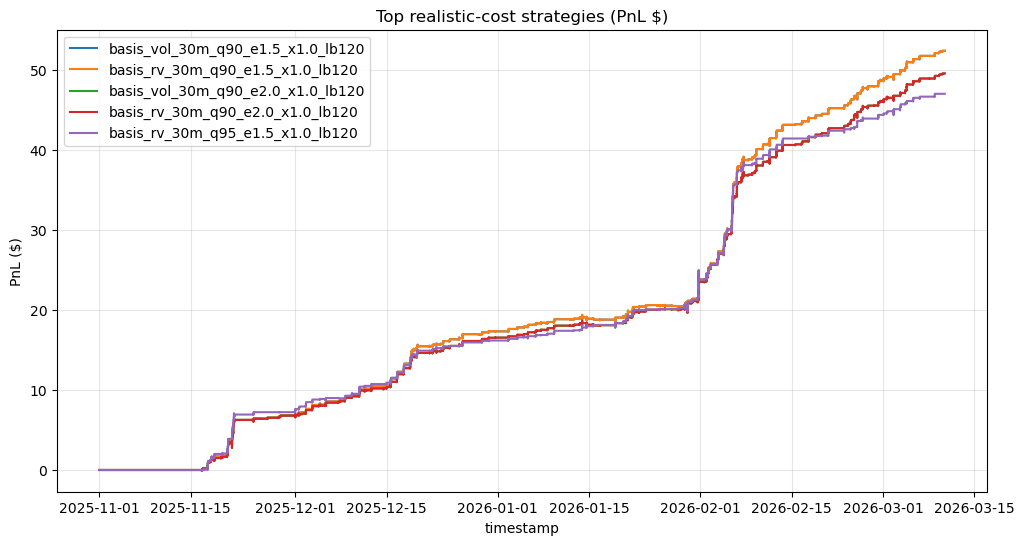

In [63]:
top_names = summary_realistic.head(5)["name"].tolist()

plt.figure(figsize=(12, 6))
for n in top_names:
    bt = bt_realistic_store[n]
    cum_pnl_dollars = bt["nav"] - bt["nav"].iloc[0]
    plt.plot(bt["timestamp"], cum_pnl_dollars, label=n)
plt.title("Top realistic-cost strategies (PnL $)")
plt.xlabel("timestamp")
plt.ylabel("PnL ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

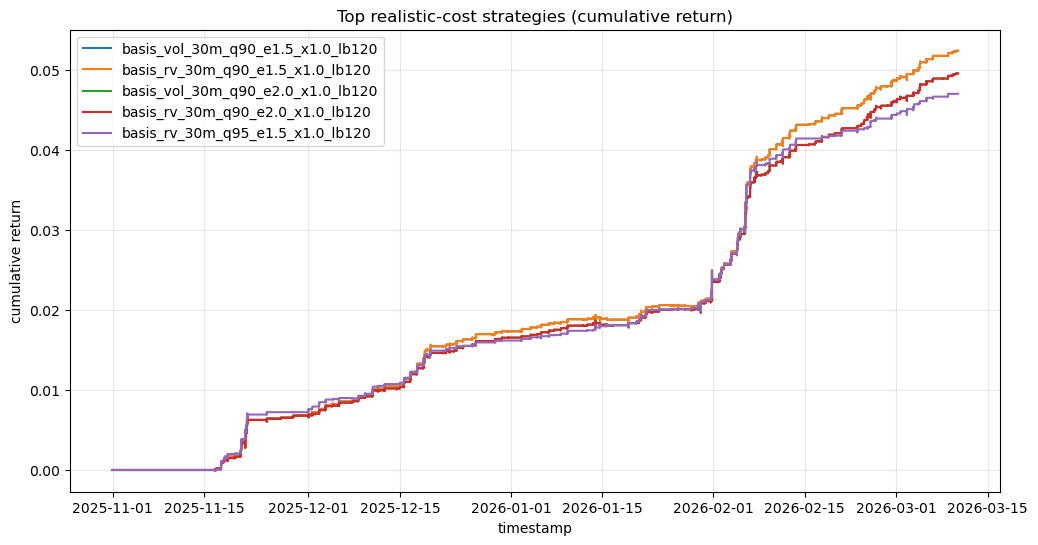

In [64]:
plt.figure(figsize=(12, 6))
for n in top_names:
    bt = bt_realistic_store[n]
    plt.plot(bt["timestamp"], bt["cum_return"], label=n)
plt.title("Top realistic-cost strategies (cumulative return)")
plt.xlabel("timestamp")
plt.ylabel("cumulative return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Final notebook takeaways

### Main conclusions

1. Simple suppression of high-activity regimes is not the main source of improvement.
2. Basis-native regime signals are stronger than a naive “avoid volatility” framing.
3. The most useful signals are based on:
   - `basis_rv_30m`
   - `basis_vol_30m`
4. High-vol-only activation is generally more effective than soft suppression.
5. Under more realistic trading frictions, the preferred region shifts toward:
   - higher quantiles such as q95
   - entry_z around 2.0–2.5
   - lookback around 120, with 240 as a secondary choice

### Practical summary from the original notebook comments

- regime signal: `basis_rv_30m` or `basis_vol_30m`
- quantile: q95
- exit_z: 1.0
- basis_lookback_min: 120 best, 240 second
- entry_z: 2.0 or 2.5 both reasonable

This is the strongest practical version under the notebook's more realistic friction assumptions.

## New experiment: combine basis activity with predicted spot volatility

So far we found:

- basis-native high-activity regimes are strong
- predicted spot vol high-only also beats no-filter after fixing the sample issue
- but predicted vol is weaker than basis-native activity on its own

This suggests a new hypothesis:

> predicted spot vol may be more useful as a confirmation overlay than as a standalone primary signal.

We test two new ideas:

1. **Dual gating**  
   Only allow entry when both:
   - basis activity is high
   - predicted spot vol is high

2. **Basis gating + predicted-vol sizing**  
   Use basis activity to decide whether trading is allowed, and use predicted spot vol to scale position size.

In [66]:
def rolling_quantile_threshold(signal: pd.Series, q: float, lookback_min: int = 30 * 24 * 60, freq_min: int = 1):
    W = int(round(lookback_min / freq_min))
    thr = (
        signal.rolling(W, min_periods=max(100, int(0.5 * W)))
              .quantile(q)
              .shift(1)
    )
    return thr


def make_high_regime_mask(signal: pd.Series, q: float, lookback_min: int = 30 * 24 * 60, freq_min: int = 1):
    thr = rolling_quantile_threshold(signal, q=q, lookback_min=lookback_min, freq_min=freq_min)
    mask = (signal >= thr)
    mask = mask.fillna(False)
    return mask, thr


def rolling_percentile_rank(signal: pd.Series, lookback_min: int = 30 * 24 * 60, freq_min: int = 1):
    W = int(round(lookback_min / freq_min))

    def last_rank(x):
        s = pd.Series(x)
        return s.rank(pct=True).iloc[-1]

    out = signal.rolling(W, min_periods=max(100, int(0.5 * W))).apply(last_rank, raw=False).shift(1)
    return out

In [67]:
def run_basis_zscore_strategy_with_entry_mask(
    df: pd.DataFrame,
    entry_mask: pd.Series,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2g.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
):
    out = (
        df.copy()
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"], keep="last")
          .reset_index(drop=True)
    )

    entry_mask = pd.Series(entry_mask).reindex(out.index)
    entry_mask = entry_mask.fillna(False).astype(bool)

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            continue

        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        if prev_pos == 0 and bool(entry_mask.iloc[i]):
            if z > entry_z:
                prev_pos = -1
            elif z < -entry_z:
                prev_pos = 1

        pos[i] = prev_pos

    out["position"] = pos
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)

    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]

    return out

In [68]:
def run_basis_zscore_strategy_with_entry_mask_and_size(
    df: pd.DataFrame,
    entry_mask: pd.Series,
    size_multiplier: pd.Series,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
):
    out = (
        df.copy()
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"], keep="last")
          .reset_index(drop=True)
    )

    entry_mask = pd.Series(entry_mask).reindex(out.index).fillna(False).astype(bool)
    size_multiplier = pd.Series(size_multiplier).reindex(out.index).fillna(0.0).astype(float)

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    raw_pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev_pos = raw_pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            raw_pos[i] = prev_pos
            continue

        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        if prev_pos == 0 and bool(entry_mask.iloc[i]):
            if z > entry_z:
                prev_pos = -1
            elif z < -entry_z:
                prev_pos = 1

        raw_pos[i] = prev_pos

    out["raw_position"] = raw_pos
    out["size_multiplier"] = size_multiplier
    out["position"] = out["raw_position"] * out["size_multiplier"]

    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)

    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]

    return out

## Build candidate regime masks

We test:

- basis-only high regime
- predicted-vol-only high regime
- dual high regime = basis high AND predicted-vol high

In [84]:
lookback_min_regime = 30 * 24 * 60

basis_mask_q80, basis_thr_q80 = make_high_regime_mask(
    df_all["basis_rv_30m"], q=0., lookback_min=lookback_min_regime, freq_min=1
)

pred_mask_q70, pred_thr_q70 = make_high_regime_mask(
    df_all["pred_vol_spot_30m"], q=0.70, lookback_min=lookback_min_regime, freq_min=1
)

pred_mask_q80, pred_thr_q80 = make_high_regime_mask(
    df_all["pred_vol_spot_30m"], q=0.80, lookback_min=lookback_min_regime, freq_min=1
)

dual_mask_q70 = basis_mask_q80 & pred_mask_q70
dual_mask_q80 = basis_mask_q80 & pred_mask_q80

print("basis high q80 bars:", int(basis_mask_q80.sum()))
print("pred high q70 bars:", int(pred_mask_q70.sum()))
print("pred high q80 bars:", int(pred_mask_q80.sum()))
print("dual q70 bars:", int(dual_mask_q70.sum()))
print("dual q80 bars:", int(dual_mask_q80.sum()))

basis high q80 bars: 162900
pred high q70 bars: 39067
pred high q80 bars: 26969
dual q70 bars: 39067
dual q80 bars: 26969


In [77]:
cost = 7.5
lookback = 120
entry = 2.0
bt_basis_only_q80 = run_basis_zscore_strategy_with_entry_mask(
    df_all,
    entry_mask=basis_mask_q80,
    basis_lookback_min=lookback,
    freq_min=1,
    entry_z=entry,
    exit_z=1.0,
    cost_bps=cost,
)

bt_pred_only_q70 = run_basis_zscore_strategy_with_entry_mask(
    df_all,
    entry_mask=pred_mask_q70,
    basis_lookback_min=lookback,
    freq_min=1,
    entry_z=entry,
    exit_z=1.0,
    cost_bps=cost,
)

bt_pred_only_q80 = run_basis_zscore_strategy_with_entry_mask(
    df_all,
    entry_mask=pred_mask_q80,
    basis_lookback_min=lookback,
    freq_min=1,
    entry_z=entry,
    exit_z=1.0,
    cost_bps=cost,
)

bt_dual_q70 = run_basis_zscore_strategy_with_entry_mask(
    df_all,
    entry_mask=dual_mask_q70,
    basis_lookback_min=lookback,
    freq_min=1,
    entry_z=entry,
    exit_z=1.0,
    cost_bps=cost,
)

bt_dual_q80 = run_basis_zscore_strategy_with_entry_mask(
    df_all,
    entry_mask=dual_mask_q80,
    basis_lookback_min=lookback,
    freq_min=1,
    entry_z=entry,
    exit_z=1.0,
    cost_bps=cost,
)

In [78]:
def trade_stats(bt: pd.DataFrame) -> pd.Series:
    x = bt.copy()
    opens = ((x["position"] != 0) & (x["position"].shift(1).fillna(0) == 0))
    closes = ((x["position"] == 0) & (x["position"].shift(1).fillna(0) != 0))

    trade_open_idx = list(x.index[opens])
    trade_close_idx = list(x.index[closes])

    if len(trade_close_idx) < len(trade_open_idx):
        trade_close_idx = trade_close_idx + [x.index[-1]]

    pnls = []
    holds = []
    for o, c in zip(trade_open_idx, trade_close_idx):
        if c < o:
            continue
        seg = x.loc[o:c]
        pnls.append(seg["net_pnl"].sum())
        holds.append(len(seg))

    return pd.Series({
        "n_trade_opens": int(opens.sum()),
        "avg_trade_pnl": np.mean(pnls) if len(pnls) else np.nan,
        "median_trade_pnl": np.median(pnls) if len(pnls) else np.nan,
        "avg_holding_bars": np.mean(holds) if len(holds) else np.nan,
    })


compare_dict = {
    "baseline": bt_baseline if "bt_baseline" in globals() else bt_no,
    "basis_only_q80": bt_basis_only_q80,
    "pred_only_q70": bt_pred_only_q70,
    "pred_only_q80": bt_pred_only_q80,
    "dual_q70": bt_dual_q70,
    "dual_q80": bt_dual_q80,
}

rows = []
for name, bt in compare_dict.items():
    s1 = summarize_backtest(bt, freq_min=1)
    s2 = trade_stats(bt)
    row = {**s1.to_dict(), **s2.to_dict(), "strategy": name}
    rows.append(row)

compare_dual = pd.DataFrame(rows).set_index("strategy").sort_values("sharpe", ascending=False)
compare_dual

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars
strategy,,,,,,,,,,,
baseline,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0,0.000130,-0.000179,4.684288
dual_q80,-0.855449,0.178389,-4.795423,-0.300368,1.582132,-0.361537,184550.0,1255.0,-0.000239,-0.000622,2.879681
dual_q70,-1.254909,0.181100,-6.929385,-0.440627,1.695373,-0.463390,184550.0,1424.0,-0.000309,-0.000702,2.839185
basis_only_q80,-2.233280,0.222465,-10.038794,-0.784155,2.473845,-0.832733,184550.0,2172.0,-0.000361,-0.000763,2.813076
pred_only_q80,-2.611862,0.182541,-14.308358,-0.917084,1.655416,-0.929598,184550.0,1715.0,-0.000535,-0.000986,2.836735
pred_only_q70,-5.320711,0.190476,-27.933755,-1.868221,1.857779,-1.868221,184550.0,2484.0,-0.000752,-0.001196,2.767713


## Basis gating + predicted-vol sizing

Now we keep basis activity as the primary gating signal, and use predicted spot vol as a sizing overlay.

This tests whether predicted vol improves the quality of trades without needing to become the main gating rule.

In [72]:
pred_rank = rolling_percentile_rank(
    df_all["pred_vol_spot_30m"],
    lookback_min=30 * 24 * 60,
    freq_min=1,
)

# Inverted-U style sizing:
# very low predicted vol -> smaller
# medium/high predicted vol -> larger
# extreme predicted vol -> slightly reduced again
size_overlay = pd.Series(0.0, index=df_all.index, dtype=float)

size_overlay[(pred_rank >= 0.00) & (pred_rank < 0.50)] = 0.50
size_overlay[(pred_rank >= 0.50) & (pred_rank < 0.80)] = 0.80
size_overlay[(pred_rank >= 0.80) & (pred_rank < 0.95)] = 1.00
size_overlay[(pred_rank >= 0.95)] = 0.70

# If pred rank unavailable early on, keep flat
size_overlay = size_overlay.fillna(0.0)

bt_basis_plus_pred_size = run_basis_zscore_strategy_with_entry_mask_and_size(
    df_all,
    entry_mask=basis_mask_q80,
    size_multiplier=size_overlay,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=1.5,
    exit_z=1.0,
    cost_bps=2.0,
)

In [73]:
compare_dict_2 = {
    "baseline": bt_baseline if "bt_baseline" in globals() else bt_no,
    "basis_only_q80": bt_basis_only_q80,
    "dual_q70": bt_dual_q70,
    "dual_q80": bt_dual_q80,
    "basis_plus_pred_size": bt_basis_plus_pred_size,
}

rows = []
for name, bt in compare_dict_2.items():
    s1 = summarize_backtest(bt, freq_min=1)
    s2 = trade_stats(bt)
    row = {**s1.to_dict(), **s2.to_dict(), "strategy": name}
    rows.append(row)

compare_overlay = pd.DataFrame(rows).set_index("strategy").sort_values("sharpe", ascending=False)
compare_overlay

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars
strategy,,,,,,,,,,,
basis_only_q80,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,0.000727,0.000339,2.948390
basis_plus_pred_size,2.664684,0.146430,18.197667,0.935630,1.513070,-0.019118,184550.0,1729.0,0.000541,0.000249,2.901099
dual_q70,3.335473,0.184336,18.094556,1.171160,1.760360,-0.026417,184550.0,1473.0,0.000795,0.000445,2.949084
dual_q80,3.214770,0.182215,17.642703,1.128778,1.647178,-0.026100,184550.0,1296.0,0.000871,0.000530,2.988426
baseline,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0,0.000130,-0.000179,4.684288


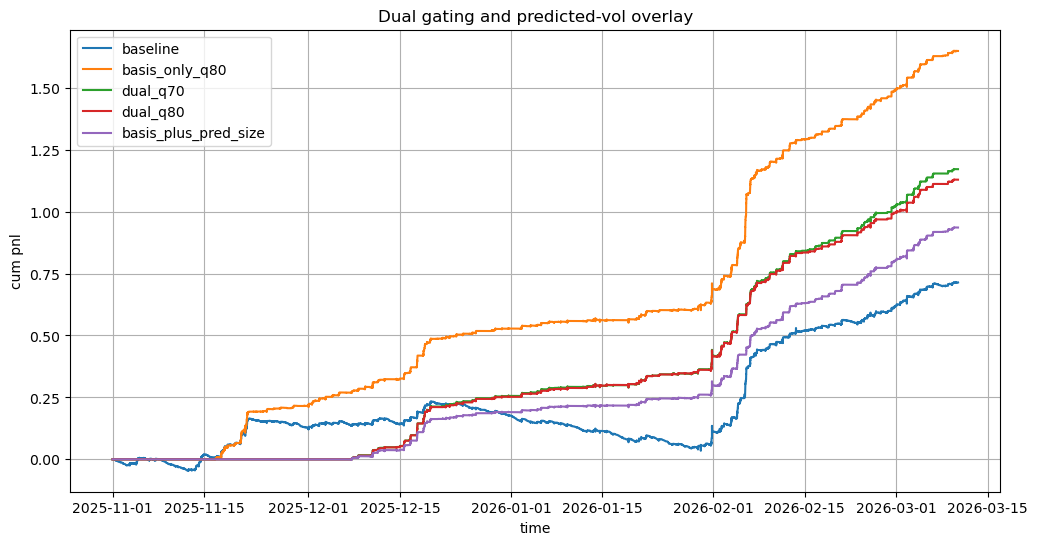

In [74]:
plot_cum_pnl(
    {
        "baseline": compare_dict_2["baseline"],
        "basis_only_q80": compare_dict_2["basis_only_q80"],
        "dual_q70": compare_dict_2["dual_q70"],
        "dual_q80": compare_dict_2["dual_q80"],
        "basis_plus_pred_size": compare_dict_2["basis_plus_pred_size"],
    },
    pnl_col="net_pnl",
    title="Dual gating and predicted-vol overlay"
)

In [79]:
lookback_min_regime = 30 * 24 * 60

basis_mask_q90, basis_thr_q90 = make_high_regime_mask(
    df_all["basis_rv_30m"], q=0.90, lookback_min=lookback_min_regime, freq_min=1
)

pred_mask_q60, pred_thr_q60 = make_high_regime_mask(
    df_all["pred_vol_spot_30m"], q=0.60, lookback_min=lookback_min_regime, freq_min=1
)

pred_mask_q70, pred_thr_q70 = make_high_regime_mask(
    df_all["pred_vol_spot_30m"], q=0.70, lookback_min=lookback_min_regime, freq_min=1
)

pred_mask_q80, pred_thr_q80 = make_high_regime_mask(
    df_all["pred_vol_spot_30m"], q=0.80, lookback_min=lookback_min_regime, freq_min=1
)

dual_mask_q60 = basis_mask_q90 & pred_mask_q60
dual_mask_q70 = basis_mask_q90 & pred_mask_q70
dual_mask_q80 = basis_mask_q90 & pred_mask_q80

print("basis high q90 bars:", int(basis_mask_q90.sum()))
print("pred high q60 bars:", int(pred_mask_q60.sum()))
print("pred high q70 bars:", int(pred_mask_q70.sum()))
print("pred high q80 bars:", int(pred_mask_q80.sum()))
print("dual q60 bars:", int(dual_mask_q60.sum()))
print("dual q70 bars:", int(dual_mask_q70.sum()))
print("dual q80 bars:", int(dual_mask_q80.sum()))

basis high q90 bars: 17132
pred high q60 bars: 50797
pred high q70 bars: 39067
pred high q80 bars: 26969
dual q60 bars: 12215
dual q70 bars: 11993
dual q80 bars: 11207


In [117]:
# =========================
# Adjustable parameters
# =========================
basis_signal_col = "basis_rv_30m"
pred_signal_col = "pred_vol_spot_30m"

basis_q = 0.90
pred_q_list = [0.60, 0.70, 0.80]

lookback_min_regime = 30 * 24 * 60   # for rolling quantile regime threshold
basis_lookback_min = 120             # for basis z-score strategy
freq_min = 1

entry_z = 1.5
exit_z = 0.5
cost_bps = 10.0

# =========================
# Build masks
# =========================
basis_mask, basis_thr = make_high_regime_mask(
    df_all[basis_signal_col],
    q=basis_q,
    lookback_min=lookback_min_regime,
    freq_min=freq_min,
)

pred_masks = {}
pred_thrs = {}
for q in pred_q_list:
    m, t = make_high_regime_mask(
        df_all[pred_signal_col],
        q=q,
        lookback_min=lookback_min_regime,
        freq_min=freq_min,
    )
    pred_masks[q] = m
    pred_thrs[q] = t

dual_masks = {q: (basis_mask & pred_masks[q]) for q in pred_q_list}

# =========================
# Run backtests
# =========================
bt_runs = {}

# basis-only
basis_name = f"basis_only_q{int(basis_q*100)}"
bt_runs[basis_name] = run_basis_zscore_strategy_with_entry_mask(
    df_all,
    entry_mask=basis_mask,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
)

# pred-only
for q in pred_q_list:
    name = f"pred_only_q{int(q*100)}"
    bt_runs[name] = run_basis_zscore_strategy_with_entry_mask(
        df_all,
        entry_mask=pred_masks[q],
        basis_lookback_min=basis_lookback_min,
        freq_min=freq_min,
        entry_z=entry_z,
        exit_z=exit_z,
        cost_bps=cost_bps,
    )

# dual
for q in pred_q_list:
    name = f"dual_basisq{int(basis_q*100)}_predq{int(q*100)}"
    bt_runs[name] = run_basis_zscore_strategy_with_entry_mask(
        df_all,
        entry_mask=dual_masks[q],
        basis_lookback_min=basis_lookback_min,
        freq_min=freq_min,
        entry_z=entry_z,
        exit_z=exit_z,
        cost_bps=cost_bps,
    )

# =========================
# Quick diagnostics
# =========================
print(f"basis regime q{int(basis_q*100)} bars:", int(basis_mask.sum()))
for q in pred_q_list:
    print(f"pred regime q{int(q*100)} bars:", int(pred_masks[q].sum()))
for q in pred_q_list:
    print(f"dual regime basis q{int(basis_q*100)} & pred q{int(q*100)} bars:", int(dual_masks[q].sum()))

list(bt_runs.keys())

basis regime q90 bars: 17132
pred regime q60 bars: 50797
pred regime q70 bars: 39067
pred regime q80 bars: 26969
dual regime basis q90 & pred q60 bars: 12215
dual regime basis q90 & pred q70 bars: 11993
dual regime basis q90 & pred q80 bars: 11207


['basis_only_q90',
 'pred_only_q60',
 'pred_only_q70',
 'pred_only_q80',
 'dual_basisq90_predq60',
 'dual_basisq90_predq70',
 'dual_basisq90_predq80']

In [118]:
def trade_stats(bt: pd.DataFrame) -> pd.Series:
    x = bt.copy()
    opens = ((x["position"] != 0) & (x["position"].shift(1).fillna(0) == 0))
    closes = ((x["position"] == 0) & (x["position"].shift(1).fillna(0) != 0))

    trade_open_idx = list(x.index[opens])
    trade_close_idx = list(x.index[closes])

    if len(trade_close_idx) < len(trade_open_idx):
        trade_close_idx = trade_close_idx + [x.index[-1]]

    pnls = []
    holds = []
    for o, c in zip(trade_open_idx, trade_close_idx):
        if c < o:
            continue
        seg = x.loc[o:c]
        pnls.append(seg["net_pnl"].sum())
        holds.append(len(seg))

    return pd.Series({
        "n_trade_opens": int(opens.sum()),
        "avg_trade_pnl": np.mean(pnls) if len(pnls) else np.nan,
        "median_trade_pnl": np.median(pnls) if len(pnls) else np.nan,
        "avg_holding_bars": np.mean(holds) if len(holds) else np.nan,
    })

bt_baseline_current = run_basis_zscore_strategy_with_entry_mask(
    df_all,
    entry_mask=pd.Series(True, index=df_all.index),
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
)

#compare_dict = {"baseline": bt_baseline if "bt_baseline" in globals() else bt_no}
compare_dict = {
    "baseline_current": bt_baseline_current,
}
compare_dict.update(bt_runs)

rows = []
for name, bt in compare_dict.items():
    s1 = summarize_backtest(bt, freq_min=freq_min)
    s2 = trade_stats(bt)
    row = {**s1.to_dict(), **s2.to_dict(), "strategy": name}
    rows.append(row)

compare_dual_param = (
    pd.DataFrame(rows)
    .set_index("strategy")
    .sort_values("sharpe", ascending=False)
)

compare_dual_param

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars
strategy,,,,,,,,,,,
dual_basisq90_predq80,-0.572511,0.183155,-3.125832,-0.201022,1.216978,-0.251405,184550.0,709.0,-0.000284,-0.000665,3.864598
basis_only_q90,-0.763227,0.225892,-3.378722,-0.267986,1.808014,-0.371076,184550.0,1038.0,-0.000258,-0.000644,3.774566
dual_basisq90_predq70,-0.644091,0.184619,-3.488764,-0.226155,1.269845,-0.271215,184550.0,748.0,-0.000302,-0.000676,3.822193
dual_basisq90_predq60,-0.647414,0.185084,-3.497942,-0.227322,1.280678,-0.276028,184550.0,754.0,-0.000301,-0.000676,3.818302
pred_only_q80,-4.398223,0.198380,-22.170674,-1.544315,1.459685,-1.544315,184550.0,1502.0,-0.001028,-0.001464,3.862184
pred_only_q70,-7.632613,0.208904,-36.536518,-2.679982,1.652018,-2.679982,184550.0,2166.0,-0.001237,-0.001678,3.857802
pred_only_q60,-11.234398,0.219007,-51.296932,-3.944650,1.791350,-3.944650,184550.0,2868.0,-0.001375,-0.001755,3.912483
baseline_current,-57.180642,0.331274,-172.608111,-20.077411,3.817589,-20.077411,184550.0,11948.0,-0.001680,-0.001861,4.110897


In [95]:
pred_rank = rolling_percentile_rank(
    df_all["pred_vol_spot_30m"],
    lookback_min=30 * 24 * 60,
    freq_min=1,
)

# Inverted-U style sizing
size_overlay = pd.Series(0.0, index=df_all.index, dtype=float)

size_overlay[(pred_rank >= 0.00) & (pred_rank < 0.50)] = 0.50
size_overlay[(pred_rank >= 0.50) & (pred_rank < 0.80)] = 0.80
size_overlay[(pred_rank >= 0.80) & (pred_rank < 0.95)] = 1.00
size_overlay[(pred_rank >= 0.95)] = 0.70

size_overlay = size_overlay.fillna(0.0)

bt_basis_q90_plus_pred_size = run_basis_zscore_strategy_with_entry_mask_and_size(
    df_all,
    entry_mask=basis_mask_q90,
    size_multiplier=size_overlay,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=1.5,
    exit_z=1.0,
    cost_bps=2.0,
)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/luzhanyue/anaconda3/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/hf/yshrdhps6xn3rb_hk1nww00m0000gn/T/ipykernel_64705/3977146709.py", line 1, in <module>
    pred_rank = rolling_percentile_rank(
                ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/hf/yshrdhps6xn3rb_hk1nww00m0000gn/T/ipykernel_64705/1599177797.py", line 25, in rolling_percentile_rank
    out = signal.rolling(W, min_periods=max(100, int(0.5 * W))).apply(last_rank, raw=False).shift(1)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/luzhanyue/anaconda3/lib/python3.11/site-packages/pandas/core/window/rolling.py", line 2043, in apply
    return super().apply(
           ^^^^^^^^^^^^^^
  File "/Users/luzhanyue/anaconda3/lib/python3.11/site-packages/pandas/core/window/rolling.py", line 1503, in ap

In [88]:
compare_dict_2 = {
    "baseline": bt_baseline if "bt_baseline" in globals() else bt_no,
    "basis_only_q90": bt_basis_only_q90,
    "dual_q60": bt_dual_q60,
    "dual_q70": bt_dual_q70,
    "dual_q80": bt_dual_q80,
    "basis_q90_plus_pred_size": bt_basis_q90_plus_pred_size,
}

rows = []
for name, bt in compare_dict_2.items():
    s1 = summarize_backtest(bt, freq_min=1)
    s2 = trade_stats(bt)
    row = {**s1.to_dict(), **s2.to_dict(), "strategy": name}
    rows.append(row)

compare_overlay_q90 = pd.DataFrame(rows).set_index("strategy").sort_values("sharpe", ascending=False)
compare_overlay_q90

NameError: name 'bt_basis_only_q90' is not defined

In [ ]:
plot_cum_pnl(
    {
        "baseline": compare_dict_2["baseline"],
        "basis_only_q90": compare_dict_2["basis_only_q90"],
        "dual_q60": compare_dict_2["dual_q60"],
        "dual_q70": compare_dict_2["dual_q70"],
        "dual_q80": compare_dict_2["dual_q80"],
        "basis_q90_plus_pred_size": compare_dict_2["basis_q90_plus_pred_size"],
    },
    pnl_col="net_pnl",
    title="Basis q90 with predicted-vol overlay"
)

## Signal-form comparison: standard z-score vs robust z-score vs percentile rank

Before using predicted volatility to filter marginal trades, we first test whether the current basis entry/exit normalization itself is appropriate.

We compare three ways to measure basis dislocation:

1. standard rolling z-score
2. robust z-score using rolling median and MAD
3. rolling percentile rank of basis

This helps answer whether mean/std normalization is suitable, or whether a more robust / nonparametric scaling is better.

In [119]:
def rolling_mad(x: pd.Series, window: int, min_periods: int | None = None) -> pd.Series:
    if min_periods is None:
        min_periods = window

    def _mad(arr):
        s = pd.Series(arr)
        med = s.median()
        return np.median(np.abs(s - med))

    return x.rolling(window, min_periods=min_periods).apply(_mad, raw=False)


def rolling_percentile_rank_of_last(x: pd.Series, window: int, min_periods: int | None = None) -> pd.Series:
    if min_periods is None:
        min_periods = window

    def _last_rank(arr):
        s = pd.Series(arr)
        return s.rank(pct=True).iloc[-1]

    return x.rolling(window, min_periods=min_periods).apply(_last_rank, raw=False)

In [120]:
def run_basis_strategy_standard_z(
    df: pd.DataFrame,
    basis_lookback_min: int = 120,
    freq_min: int = 1,
    entry_z: float = 1.5,
    exit_z: float = 1.0,
    cost_bps: float = 2.0,
    entry_mask: pd.Series | None = None,
):
    out = df.copy().sort_values("timestamp").reset_index(drop=True)

    if entry_mask is None:
        entry_mask = pd.Series(True, index=out.index)
    else:
        entry_mask = pd.Series(entry_mask).reindex(out.index).fillna(False).astype(bool)

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["signal"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev = pos[i - 1]
        s = out.at[i, "signal"]

        if pd.isna(s):
            pos[i] = prev
            continue

        if prev == 1 and abs(s) < exit_z:
            prev = 0
        elif prev == -1 and abs(s) < exit_z:
            prev = 0

        if prev == 0 and bool(entry_mask.iloc[i]):
            if s > entry_z:
                prev = -1
            elif s < -entry_z:
                prev = 1

        pos[i] = prev

    out["position"] = pos
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out

In [121]:
def run_basis_strategy_robust_z(
    df: pd.DataFrame,
    basis_lookback_min: int = 120,
    freq_min: int = 1,
    entry_z: float = 1.5,
    exit_z: float = 1.0,
    cost_bps: float = 2.0,
    entry_mask: pd.Series | None = None,
):
    out = df.copy().sort_values("timestamp").reset_index(drop=True)

    if entry_mask is None:
        entry_mask = pd.Series(True, index=out.index)
    else:
        entry_mask = pd.Series(entry_mask).reindex(out.index).fillna(False).astype(bool)

    W = int(round(basis_lookback_min / freq_min))
    out["basis_median"] = out["basis"].rolling(W, min_periods=W).median()
    out["basis_mad"] = rolling_mad(out["basis"], window=W, min_periods=W)

    # 1.4826 * MAD ~ std under Gaussian, keeps scale comparable
    out["signal"] = (out["basis"] - out["basis_median"]) / (1.4826 * out["basis_mad"] + 1e-12)

    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev = pos[i - 1]
        s = out.at[i, "signal"]

        if pd.isna(s):
            pos[i] = prev
            continue

        if prev == 1 and abs(s) < exit_z:
            prev = 0
        elif prev == -1 and abs(s) < exit_z:
            prev = 0

        if prev == 0 and bool(entry_mask.iloc[i]):
            if s > entry_z:
                prev = -1
            elif s < -entry_z:
                prev = 1

        pos[i] = prev

    out["position"] = pos
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out

In [122]:
def run_basis_strategy_percentile(
    df: pd.DataFrame,
    basis_lookback_min: int = 120,
    freq_min: int = 1,
    entry_q: float = 0.90,
    exit_band_low: float = 0.35,
    exit_band_high: float = 0.65,
    cost_bps: float = 2.0,
    entry_mask: pd.Series | None = None,
):
    """
    Percentile signal:
      - enter short if current basis is in the top entry_q percentile of recent window
      - enter long  if current basis is in the bottom (1-entry_q) percentile
      - exit when percentile returns to central band
    """
    out = df.copy().sort_values("timestamp").reset_index(drop=True)

    if entry_mask is None:
        entry_mask = pd.Series(True, index=out.index)
    else:
        entry_mask = pd.Series(entry_mask).reindex(out.index).fillna(False).astype(bool)

    W = int(round(basis_lookback_min / freq_min))
    out["basis_pct_rank"] = rolling_percentile_rank_of_last(out["basis"], window=W, min_periods=W)

    pos = np.zeros(len(out), dtype=float)
    lower_entry = 1.0 - entry_q

    for i in range(1, len(out)):
        prev = pos[i - 1]
        p = out.at[i, "basis_pct_rank"]

        if pd.isna(p):
            pos[i] = prev
            continue

        if prev == 1 and (exit_band_low <= p <= exit_band_high):
            prev = 0
        elif prev == -1 and (exit_band_low <= p <= exit_band_high):
            prev = 0

        if prev == 0 and bool(entry_mask.iloc[i]):
            if p >= entry_q:
                prev = -1
            elif p <= lower_entry:
                prev = 1

        pos[i] = prev

    out["position"] = pos
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out

In [123]:
def trade_stats(bt: pd.DataFrame) -> pd.Series:
    x = bt.copy()
    opens = ((x["position"] != 0) & (x["position"].shift(1).fillna(0) == 0))
    closes = ((x["position"] == 0) & (x["position"].shift(1).fillna(0) != 0))

    trade_open_idx = list(x.index[opens])
    trade_close_idx = list(x.index[closes])

    if len(trade_close_idx) < len(trade_open_idx):
        trade_close_idx = trade_close_idx + [x.index[-1]]

    pnls = []
    holds = []
    for o, c in zip(trade_open_idx, trade_close_idx):
        if c < o:
            continue
        seg = x.loc[o:c]
        pnls.append(seg["net_pnl"].sum())
        holds.append(len(seg))

    return pd.Series({
        "n_trade_opens": int(opens.sum()),
        "avg_trade_pnl": np.mean(pnls) if len(pnls) else np.nan,
        "median_trade_pnl": np.median(pnls) if len(pnls) else np.nan,
        "avg_holding_bars": np.mean(holds) if len(holds) else np.nan,
    })

## Run signal-form comparison

Start with the same broad strategy parameters across all three variants, so the comparison focuses on signal normalization rather than parameter tuning.

In [125]:
# =========================
# Adjustable parameters
# =========================
basis_lookback_min = 120
freq_min = 1
cost_bps = 2.0

# For standard / robust z
entry_z = 1.5
exit_z = 1.0

# For percentile version
entry_q = 0.90
exit_band_low = 0.35
exit_band_high = 0.65

# Optional regime filter:
# use all bars first
entry_mask = pd.Series(True, index=df_all.index)

bt_std = run_basis_strategy_standard_z(
    df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    entry_mask=entry_mask,
)

bt_robust = run_basis_strategy_robust_z(
    df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    entry_mask=entry_mask,
)

bt_pct = run_basis_strategy_percentile(
    df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_q=entry_q,
    exit_band_low=exit_band_low,
    exit_band_high=exit_band_high,
    cost_bps=cost_bps,
    entry_mask=entry_mask,
)

In [126]:
compare_signal_form = {}

for name, bt in {
    "standard_z": bt_std,
    "robust_z": bt_robust,
    "percentile": bt_pct,
}.items():
    s1 = summarize_backtest(bt, freq_min=freq_min)
    s2 = trade_stats(bt)
    compare_signal_form[name] = {**s1.to_dict(), **s2.to_dict()}

compare_signal_form = pd.DataFrame(compare_signal_form).T.sort_values("sharpe", ascending=False)
compare_signal_form

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars
standard_z,-3.825487,0.234635,-16.303983,-1.343215,4.242185,-1.644727,184550.0,13964.0,-0.000096,-0.000268,2.770338
percentile,-10.767261,0.284024,-37.909660,-3.780628,3.565572,-3.780628,184550.0,18366.0,-0.000206,-0.000286,5.319503
robust_z,-11.169155,0.277168,-40.297393,-3.921742,4.661658,-3.921742,184550.0,21459.0,-0.000183,-0.000276,3.030104


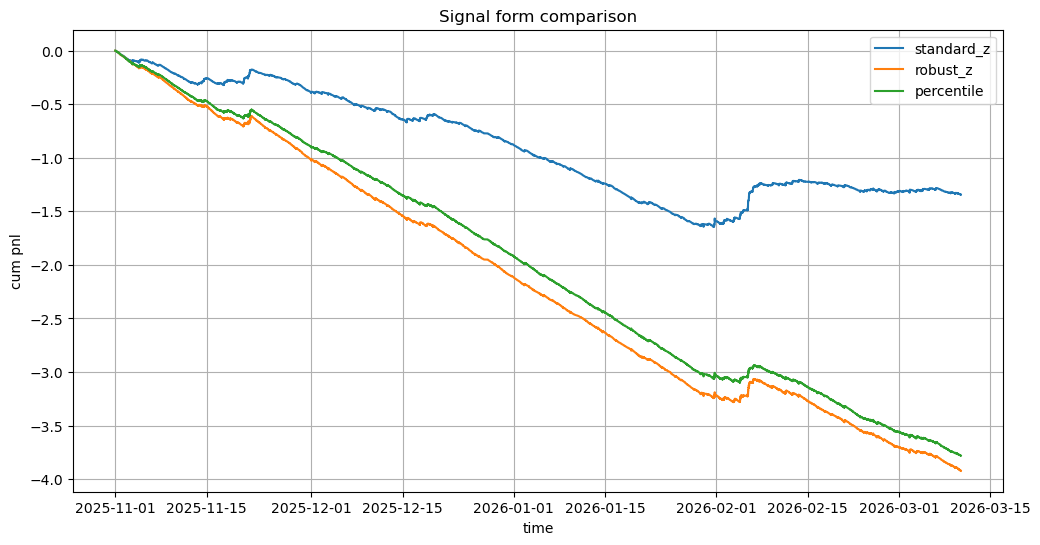

In [127]:
plot_cum_pnl(
    {
        "standard_z": bt_std,
        "robust_z": bt_robust,
        "percentile": bt_pct,
    },
    pnl_col="net_pnl",
    title="Signal form comparison"
)

## test under the stronger basis regime only

After the all-bars comparison, we can repeat the same signal-form comparison under the stronger basis regime filter (for example basis_rv_30m q90), to check whether the preferred normalization changes once we already restrict to higher-quality trading environments.

In [128]:
# Optional stronger regime filter
lookback_min_regime = 30 * 24 * 60
basis_q = 0.90

basis_mask_q90, _ = make_high_regime_mask(
    df_all["basis_rv_30m"],
    q=basis_q,
    lookback_min=lookback_min_regime,
    freq_min=freq_min,
)

bt_std_q90 = run_basis_strategy_standard_z(
    df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    entry_mask=basis_mask_q90,
)

bt_robust_q90 = run_basis_strategy_robust_z(
    df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    entry_mask=basis_mask_q90,
)

bt_pct_q90 = run_basis_strategy_percentile(
    df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_q=entry_q,
    exit_band_low=exit_band_low,
    exit_band_high=exit_band_high,
    cost_bps=cost_bps,
    entry_mask=basis_mask_q90,
)

In [129]:
compare_signal_form_q90 = {}

for name, bt in {
    "standard_z_q90": bt_std_q90,
    "robust_z_q90": bt_robust_q90,
    "percentile_q90": bt_pct_q90,
}.items():
    s1 = summarize_backtest(bt, freq_min=freq_min)
    s2 = trade_stats(bt)
    compare_signal_form_q90[name] = {**s1.to_dict(), **s2.to_dict()}

compare_signal_form_q90 = pd.DataFrame(compare_signal_form_q90).T.sort_values("sharpe", ascending=False)
compare_signal_form_q90

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars
standard_z_q90,4.388355,0.213415,20.562501,1.540850,2.009650,-0.023460,184550.0,1172.0,0.001315,0.000934,3.012799
robust_z_q90,2.568213,0.251879,10.196209,0.901757,1.891357,-0.024384,184550.0,2474.0,0.000364,-0.000034,3.890461
percentile_q90,2.056000,0.256216,8.024477,0.721908,1.300708,-0.024404,184550.0,1447.0,0.000499,0.000031,7.519005


In [130]:
#结论用standard z 还是要好得多

## Predicted-vol filter for marginal basis trades

We keep the current standard z-score framework as the main signal.

The new idea is:

- strong basis dislocations are allowed directly
- only marginal / borderline basis trades require confirmation from predicted spot volatility

This is designed to reduce low-quality trades and cost drag, without over-filtering the strongest basis opportunities.

In [132]:
def run_basis_strategy_standard_z_with_marginal_pred_filter(
    df: pd.DataFrame,
    basis_lookback_min: int = 120,
    freq_min: int = 1,
    entry_z: float = 1.5,
    exit_z: float = 1.0,
    strong_z: float = 2.5,
    pred_vol_col: str = "pred_vol_spot_30m",
    pred_q: float = 0.70,
    pred_lookback_min: int = 30 * 24 * 60,
    base_entry_mask: pd.Series | None = None,
    cost_bps: float = 2.0,
):
    """
    Main logic:
      - if |basis_z| >= strong_z: allow entry directly
      - if entry_z <= |basis_z| < strong_z: require pred_vol >= rolling q(pred_q)
      - else: no entry

    base_entry_mask:
      optional outer regime filter (e.g. basis_rv_30m q90)
    """
    out = df.copy().sort_values("timestamp").reset_index(drop=True)

    if base_entry_mask is None:
        base_entry_mask = pd.Series(True, index=out.index)
    else:
        base_entry_mask = pd.Series(base_entry_mask).reindex(out.index).fillna(False).astype(bool)

    # standard z-score
    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)
    out["abs_basis_z"] = out["basis_z"].abs()

    # pred-vol threshold
    VW = int(round(pred_lookback_min / freq_min))
    out["pred_vol_threshold"] = (
        out[pred_vol_col]
        .rolling(VW, min_periods=max(100, int(0.5 * VW)))
        .quantile(pred_q)
        .shift(1)
    )

    pred_ok = out[pred_vol_col] >= out["pred_vol_threshold"]
    pred_ok = pred_ok.fillna(False)

    # entry categories
    out["is_strong_trade"] = out["abs_basis_z"] >= strong_z
    out["is_marginal_trade"] = (out["abs_basis_z"] >= entry_z) & (out["abs_basis_z"] < strong_z)

    # allowed entry logic
    out["allow_entry"] = False
    out.loc[
        base_entry_mask & out["is_strong_trade"],
        "allow_entry"
    ] = True

    out.loc[
        base_entry_mask & out["is_marginal_trade"] & pred_ok,
        "allow_entry"
    ] = True

    # state machine
    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev
            continue

        if prev == 1 and abs(z) < exit_z:
            prev = 0
        elif prev == -1 and abs(z) < exit_z:
            prev = 0

        if prev == 0 and bool(out.at[i, "allow_entry"]):
            if z > entry_z:
                prev = -1
            elif z < -entry_z:
                prev = 1

        pos[i] = prev

    out["position"] = pos
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]

    return out

In [133]:
def trade_stats(bt: pd.DataFrame) -> pd.Series:
    x = bt.copy()
    opens = ((x["position"] != 0) & (x["position"].shift(1).fillna(0) == 0))
    closes = ((x["position"] == 0) & (x["position"].shift(1).fillna(0) != 0))

    trade_open_idx = list(x.index[opens])
    trade_close_idx = list(x.index[closes])

    if len(trade_close_idx) < len(trade_open_idx):
        trade_close_idx = trade_close_idx + [x.index[-1]]

    pnls = []
    holds = []
    for o, c in zip(trade_open_idx, trade_close_idx):
        if c < o:
            continue
        seg = x.loc[o:c]
        pnls.append(seg["net_pnl"].sum())
        holds.append(len(seg))

    return pd.Series({
        "n_trade_opens": int(opens.sum()),
        "avg_trade_pnl": np.mean(pnls) if len(pnls) else np.nan,
        "median_trade_pnl": np.median(pnls) if len(pnls) else np.nan,
        "avg_holding_bars": np.mean(holds) if len(holds) else np.nan,
    })

## Adjustable experiment parameters

You can freely change:

- the outer basis regime filter
- z-score entry / exit
- the "strong trade" threshold
- the predicted-vol confirmation threshold for marginal trades

In [139]:
# =====================================
# Adjustable parameters
# =====================================
freq_min = 1
cost_bps = 7.5

# standard z-score strategy params
basis_lookback_min = 120
entry_z = 1.5
exit_z = 1.0

# marginal-trade control:
# trades with |z| >= strong_z go through directly
# trades with entry_z <= |z| < strong_z need pred-vol confirmation
strong_z_list = [2.0, 2.25, 2.5, 2.75]

# predicted-vol confirmation threshold for marginal trades
pred_q_list = [0.60, 0.70, 0.80]

# outer basis regime filter
use_outer_basis_regime = True
basis_regime_signal_col = "basis_rv_30m"
basis_regime_q = 0.90
basis_regime_lookback_min = 30 * 24 * 60

pred_vol_col = "pred_vol_spot_30m"
pred_lookback_min = 30 * 24 * 60

# =====================================
# Build outer regime mask
# =====================================
if use_outer_basis_regime:
    outer_basis_mask, _ = make_high_regime_mask(
        df_all[basis_regime_signal_col],
        q=basis_regime_q,
        lookback_min=basis_regime_lookback_min,
        freq_min=freq_min,
    )
else:
    outer_basis_mask = pd.Series(True, index=df_all.index)

# =====================================
# Baseline under the SAME outer regime
# =====================================
bt_basis_reference = run_basis_strategy_standard_z(
    df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    entry_mask=outer_basis_mask,
)

# =====================================
# Marginal-trade filtered variants
# =====================================
bt_marginal_runs = {}

for strong_z in strong_z_list:
    for pred_q in pred_q_list:
        name = f"marginal_strongz{strong_z}_predq{int(pred_q*100)}"
        bt_marginal_runs[name] = run_basis_strategy_standard_z_with_marginal_pred_filter(
            df_all,
            basis_lookback_min=basis_lookback_min,
            freq_min=freq_min,
            entry_z=entry_z,
            exit_z=exit_z,
            strong_z=strong_z,
            pred_vol_col=pred_vol_col,
            pred_q=pred_q,
            pred_lookback_min=pred_lookback_min,
            base_entry_mask=outer_basis_mask,
            cost_bps=cost_bps,
        )

print("Reference baseline ready.")
print("Number of marginal variants:", len(bt_marginal_runs))
list(bt_marginal_runs.keys())[:5]

Reference baseline ready.
Number of marginal variants: 12


['marginal_strongz2.0_predq60',
 'marginal_strongz2.0_predq70',
 'marginal_strongz2.0_predq80',
 'marginal_strongz2.25_predq60',
 'marginal_strongz2.25_predq70']

In [140]:
compare_marginal = {
    "basis_reference": bt_basis_reference,
}
compare_marginal.update(bt_marginal_runs)

rows = []
for name, bt in compare_marginal.items():
    s1 = summarize_backtest(bt, freq_min=freq_min)
    s2 = trade_stats(bt)
    rows.append({
        "strategy": name,
        **s1.to_dict(),
        **s2.to_dict(),
    })

compare_marginal_df = (
    pd.DataFrame(rows)
    .set_index("strategy")
    .sort_values("sharpe", ascending=False)
)

compare_marginal_df

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars
strategy,,,,,,,,,,,
marginal_strongz2.75_predq80,0.961314,0.204282,4.705823,0.337539,1.816539,-0.150773,184550.0,986.0,0.000342,-0.000096,3.072008
marginal_strongz2.5_predq80,0.954087,0.205047,4.653027,0.335001,1.841001,-0.151030,184550.0,1004.0,0.000334,-0.000106,3.068725
marginal_strongz2.25_predq80,0.959190,0.207033,4.633026,0.336793,1.887793,-0.152170,184550.0,1034.0,0.000326,-0.000109,3.058027
marginal_strongz2.0_predq80,0.923098,0.207899,4.440121,0.324120,1.920120,-0.154713,184550.0,1064.0,0.000305,-0.000113,3.048872
marginal_strongz2.75_predq70,0.906552,0.204872,4.424971,0.318311,1.834811,-0.166682,184550.0,1011.0,0.000315,-0.000116,3.061325
marginal_strongz2.5_predq70,0.903927,0.205583,4.396886,0.317389,1.854889,-0.166682,184550.0,1025.0,0.000310,-0.000119,3.061463
marginal_strongz2.75_predq60,0.897061,0.204990,4.376119,0.314978,1.838978,-0.169369,184550.0,1016.0,0.000310,-0.000116,3.058071
marginal_strongz2.25_predq70,0.906071,0.207373,4.369275,0.318142,1.894642,-0.167823,184550.0,1051.0,0.000303,-0.000122,3.054234
marginal_strongz2.5_predq60,0.891273,0.205673,4.333440,0.312946,1.856446,-0.169369,184550.0,1029.0,0.000304,-0.000122,3.059281


In [141]:
# Optional: rank by lower trade count first, focus is cost control
compare_marginal_df.sort_values(
    ["cum_net_pnl", "avg_trade_pnl", "n_trade_opens"],
    ascending=[False, False, True]
)

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars
strategy,,,,,,,,,,,
marginal_strongz2.75_predq80,0.961314,0.204282,4.705823,0.337539,1.816539,-0.150773,184550.0,986.0,0.000342,-0.000096,3.072008
marginal_strongz2.25_predq80,0.959190,0.207033,4.633026,0.336793,1.887793,-0.152170,184550.0,1034.0,0.000326,-0.000109,3.058027
marginal_strongz2.5_predq80,0.954087,0.205047,4.653027,0.335001,1.841001,-0.151030,184550.0,1004.0,0.000334,-0.000106,3.068725
marginal_strongz2.0_predq80,0.923098,0.207899,4.440121,0.324120,1.920120,-0.154713,184550.0,1064.0,0.000305,-0.000113,3.048872
marginal_strongz2.75_predq70,0.906552,0.204872,4.424971,0.318311,1.834811,-0.166682,184550.0,1011.0,0.000315,-0.000116,3.061325
marginal_strongz2.25_predq70,0.906071,0.207373,4.369275,0.318142,1.894642,-0.167823,184550.0,1051.0,0.000303,-0.000122,3.054234
marginal_strongz2.5_predq70,0.903927,0.205583,4.396886,0.317389,1.854889,-0.166682,184550.0,1025.0,0.000310,-0.000119,3.061463
marginal_strongz2.75_predq60,0.897061,0.204990,4.376119,0.314978,1.838978,-0.169369,184550.0,1016.0,0.000310,-0.000116,3.058071
marginal_strongz2.25_predq60,0.895071,0.207460,4.314424,0.314280,1.896780,-0.170510,184550.0,1055.0,0.000298,-0.000123,3.051185


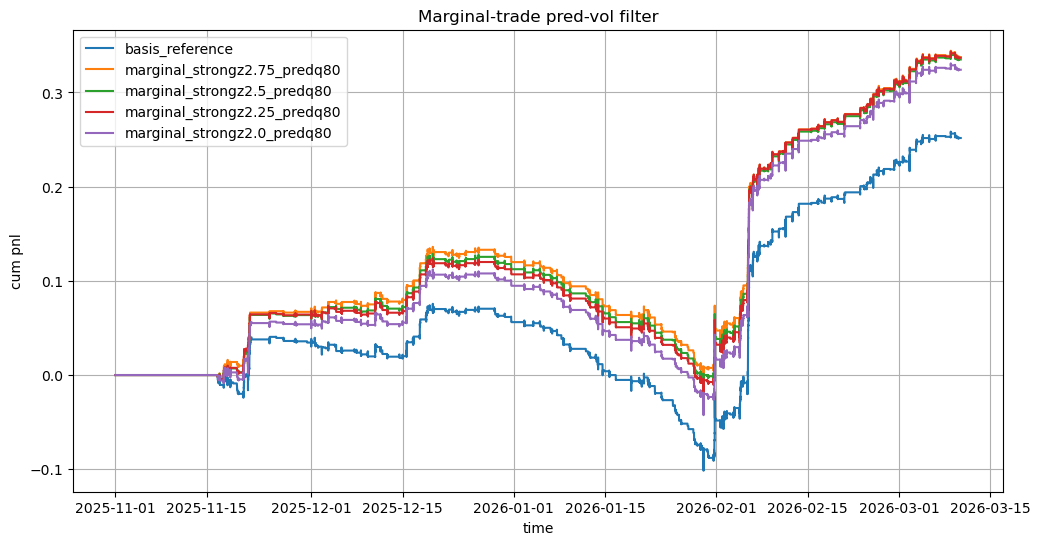

In [142]:
top_names = ["basis_reference"] + compare_marginal_df.head(4).index.tolist()
top_names = list(dict.fromkeys(top_names))  # remove duplicates while preserving order

plot_dict = {name: compare_marginal[name] for name in top_names}

plot_cum_pnl(
    plot_dict,
    pnl_col="net_pnl",
    title="Marginal-trade pred-vol filter"
)

## Investigate the effect of the Marginal-trade vs basis trade in different cost

In [143]:
# =====================================
# Cost sweep for basis_reference vs marginal pred-vol filter
# Produces:
#   1) summary_cost_sweep table
#   2) pivot tables
#   3) cost-vs-metric plots
#   4) cumulative PnL plot at a selected cost
# =====================================
# -----------------------------
# Adjustable parameters
# -----------------------------
freq_min = 1

basis_lookback_min = 120
entry_z = 1.5
exit_z = 1.0

use_outer_basis_regime = True
basis_regime_signal_col = "basis_rv_30m"
basis_regime_q = 0.90
basis_regime_lookback_min = 30 * 24 * 60

pred_vol_col = "pred_vol_spot_30m"
pred_q = 0.80
pred_lookback_min = 30 * 24 * 60

strong_z_list = [2.5, 2.75]
cost_list = [2.0, 5.0, 7.5, 10.0]

# which cost to use for the final cum-pnl comparison plot
plot_cost_bps = 7.5

# -----------------------------
# Build outer regime mask
# -----------------------------
if use_outer_basis_regime:
    outer_basis_mask, _ = make_high_regime_mask(
        df_all[basis_regime_signal_col],
        q=basis_regime_q,
        lookback_min=basis_regime_lookback_min,
        freq_min=freq_min,
    )
else:
    outer_basis_mask = pd.Series(True, index=df_all.index)

# -----------------------------
# Trade stats helper
# -----------------------------
def trade_stats(bt: pd.DataFrame) -> pd.Series:
    x = bt.copy()
    opens = ((x["position"] != 0) & (x["position"].shift(1).fillna(0) == 0))
    closes = ((x["position"] == 0) & (x["position"].shift(1).fillna(0) != 0))

    trade_open_idx = list(x.index[opens])
    trade_close_idx = list(x.index[closes])

    if len(trade_close_idx) < len(trade_open_idx):
        trade_close_idx = trade_close_idx + [x.index[-1]]

    pnls = []
    holds = []
    for o, c in zip(trade_open_idx, trade_close_idx):
        if c < o:
            continue
        seg = x.loc[o:c]
        pnls.append(seg["net_pnl"].sum())
        holds.append(len(seg))

    return pd.Series({
        "n_trade_opens": int(opens.sum()),
        "avg_trade_pnl": np.mean(pnls) if len(pnls) else np.nan,
        "median_trade_pnl": np.median(pnls) if len(pnls) else np.nan,
        "avg_holding_bars": np.mean(holds) if len(holds) else np.nan,
    })

# -----------------------------
# Run sweep
# -----------------------------
bt_cost_store = {}
rows = []

for cost_bps in cost_list:
    # baseline reference under same outer regime
    ref_name = f"basis_reference_cost{cost_bps}"
    bt_ref = run_basis_strategy_standard_z(
        df_all,
        basis_lookback_min=basis_lookback_min,
        freq_min=freq_min,
        entry_z=entry_z,
        exit_z=exit_z,
        cost_bps=cost_bps,
        entry_mask=outer_basis_mask,
    )
    bt_cost_store[ref_name] = bt_ref

    s1 = summarize_backtest(bt_ref, freq_min=freq_min)
    s2 = trade_stats(bt_ref)
    rows.append({
        "strategy": "basis_reference",
        "strong_z": np.nan,
        "pred_q": np.nan,
        "cost_bps": cost_bps,
        **s1.to_dict(),
        **s2.to_dict(),
    })

    # marginal versions
    for strong_z in strong_z_list:
        name = f"marginal_strongz{strong_z}_predq{int(pred_q*100)}_cost{cost_bps}"
        bt = run_basis_strategy_standard_z_with_marginal_pred_filter(
            df_all,
            basis_lookback_min=basis_lookback_min,
            freq_min=freq_min,
            entry_z=entry_z,
            exit_z=exit_z,
            strong_z=strong_z,
            pred_vol_col=pred_vol_col,
            pred_q=pred_q,
            pred_lookback_min=pred_lookback_min,
            base_entry_mask=outer_basis_mask,
            cost_bps=cost_bps,
        )
        bt_cost_store[name] = bt

        s1 = summarize_backtest(bt, freq_min=freq_min)
        s2 = trade_stats(bt)
        rows.append({
            "strategy": f"marginal_strongz{strong_z}_predq{int(pred_q*100)}",
            "strong_z": strong_z,
            "pred_q": pred_q,
            "cost_bps": cost_bps,
            **s1.to_dict(),
            **s2.to_dict(),
        })

summary_cost_sweep = pd.DataFrame(rows).sort_values(["cost_bps", "strategy"]).reset_index(drop=True)
summary_cost_sweep

,strategy,strong_z,pred_q,cost_bps,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars
0,basis_reference,NaN,NaN,2.0,4.388355,0.213415,20.562501,1.540850,2.009650,-0.023460,184550.0,1172.0,0.001315,0.000934,3.012799
1,marginal_strongz2.5_predq80,2.50,0.8,2.0,4.099428,0.206706,19.832146,1.439401,1.841001,-0.023460,184550.0,1004.0,0.001434,0.000994,3.068725
2,marginal_strongz2.75_predq80,2.75,0.8,2.0,4.050264,0.205918,19.669285,1.422139,1.816539,-0.023460,184550.0,986.0,0.001442,0.001004,3.072008
3,basis_reference,NaN,NaN,5.0,2.385635,0.211425,11.283575,0.837650,2.009650,-0.043382,184550.0,1172.0,0.000715,0.000334,3.012799
4,marginal_strongz2.5_predq80,2.50,0.8,5.0,2.383788,0.204769,11.641332,0.837001,1.841001,-0.033885,184550.0,1004.0,0.000834,0.000394,3.068725
5,marginal_strongz2.75_predq80,2.75,0.8,5.0,2.365382,0.204008,11.594530,0.830539,1.816539,-0.035236,184550.0,986.0,0.000842,0.000404,3.072008
6,basis_reference,NaN,NaN,7.5,0.716702,0.211902,3.382232,0.251650,2.009650,-0.177214,184550.0,1172.0,0.000215,-0.000166,3.012799
7,marginal_strongz2.5_predq80,2.50,0.8,7.5,0.954087,0.205047,4.653027,0.335001,1.841001,-0.151030,184550.0,1004.0,0.000334,-0.000106,3.068725
8,marginal_strongz2.75_predq80,2.75,0.8,7.5,0.961314,0.204282,4.705823,0.337539,1.816539,-0.150773,184550.0,986.0,0.000342,-0.000096,3.072008
9,basis_reference,NaN,NaN,10.0,-0.952231,0.214308,-4.443276,-0.334350,2.009650,-0.444118,184550.0,1172.0,-0.000285,-0.000666,3.012799


In [144]:
# Useful pivot tables
pivot_sharpe = summary_cost_sweep.pivot(index="cost_bps", columns="strategy", values="sharpe")
pivot_cum = summary_cost_sweep.pivot(index="cost_bps", columns="strategy", values="cum_net_pnl")
pivot_trades = summary_cost_sweep.pivot(index="cost_bps", columns="strategy", values="n_trade_opens")

print("Sharpe by cost")
display(pivot_sharpe)

print("Cumulative net pnl by cost")
display(pivot_cum)

print("Number of trade opens by cost")
display(pivot_trades)

Sharpe by cost


strategy,basis_reference,marginal_strongz2.5_predq80,marginal_strongz2.75_predq80
cost_bps,,,
2.0,20.562501,19.832146,19.669285
5.0,11.283575,11.641332,11.594530
7.5,3.382232,4.653027,4.705823
10.0,-4.443276,-2.297225,-2.146736


Cumulative net pnl by cost


strategy,basis_reference,marginal_strongz2.5_predq80,marginal_strongz2.75_predq80
cost_bps,,,
2.0,1.54085,1.439401,1.422139
5.0,0.83765,0.837001,0.830539
7.5,0.25165,0.335001,0.337539
10.0,-0.33435,-0.166999,-0.155461


Number of trade opens by cost


strategy,basis_reference,marginal_strongz2.5_predq80,marginal_strongz2.75_predq80
cost_bps,,,
2.0,1172.0,1004.0,986.0
5.0,1172.0,1004.0,986.0
7.5,1172.0,1004.0,986.0
10.0,1172.0,1004.0,986.0


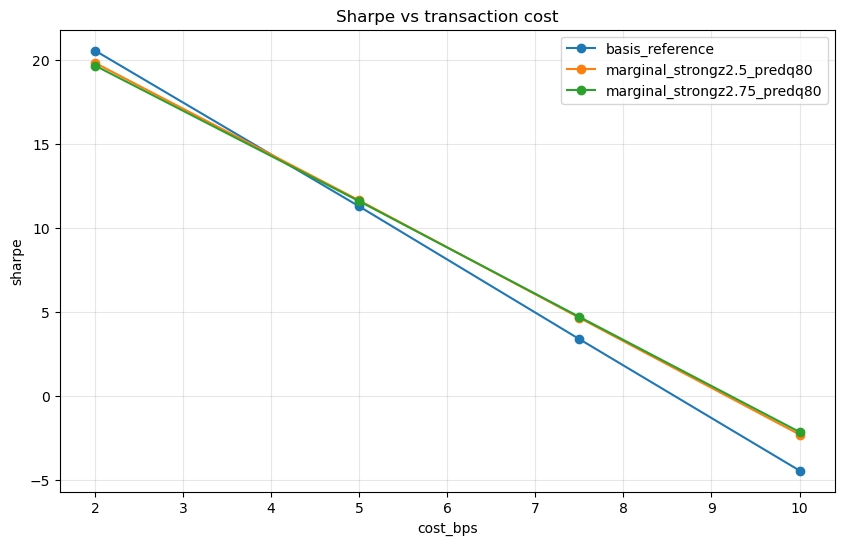

In [145]:
# Plot 1: Sharpe vs cost
plt.figure(figsize=(10, 6))
for strategy, g in summary_cost_sweep.groupby("strategy"):
    g = g.sort_values("cost_bps")
    plt.plot(g["cost_bps"], g["sharpe"], marker="o", label=strategy)

plt.title("Sharpe vs transaction cost")
plt.xlabel("cost_bps")
plt.ylabel("sharpe")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

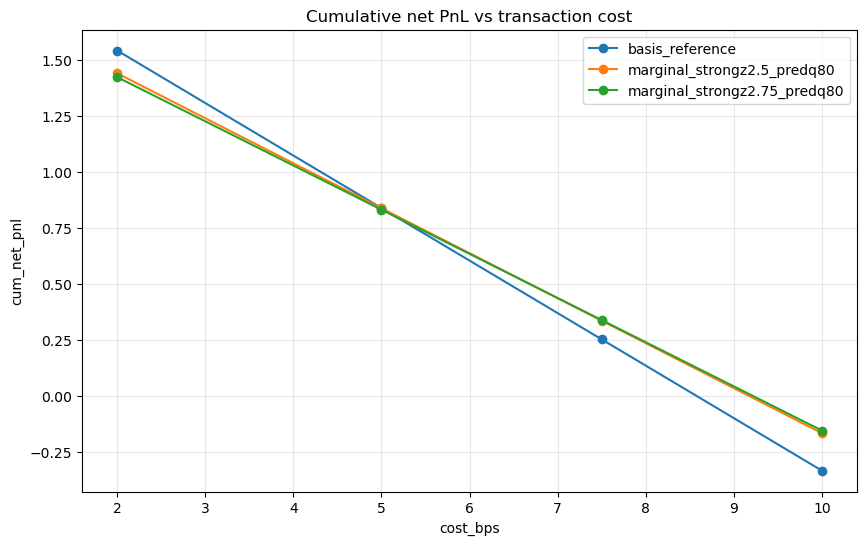

In [146]:
# Plot 2: Cum net pnl vs cost
plt.figure(figsize=(10, 6))
for strategy, g in summary_cost_sweep.groupby("strategy"):
    g = g.sort_values("cost_bps")
    plt.plot(g["cost_bps"], g["cum_net_pnl"], marker="o", label=strategy)

plt.title("Cumulative net PnL vs transaction cost")
plt.xlabel("cost_bps")
plt.ylabel("cum_net_pnl")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

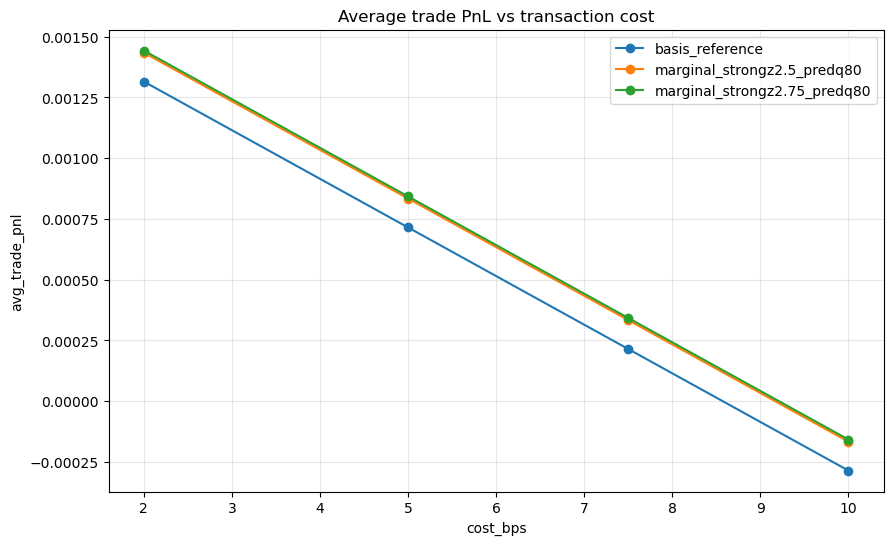

In [147]:
# Plot 3: Avg trade pnl vs cost
plt.figure(figsize=(10, 6))
for strategy, g in summary_cost_sweep.groupby("strategy"):
    g = g.sort_values("cost_bps")
    plt.plot(g["cost_bps"], g["avg_trade_pnl"], marker="o", label=strategy)

plt.title("Average trade PnL vs transaction cost")
plt.xlabel("cost_bps")
plt.ylabel("avg_trade_pnl")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

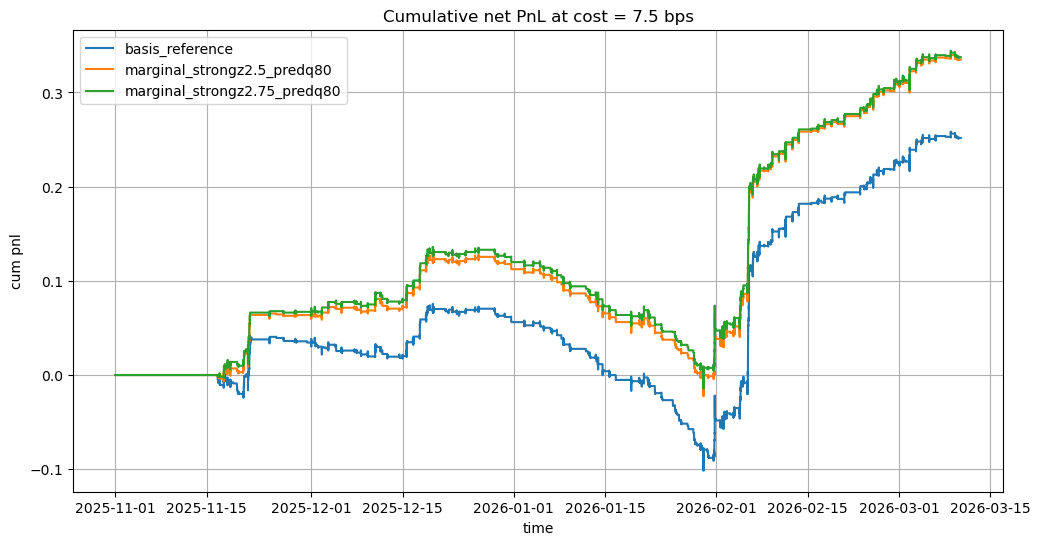

In [148]:
# Plot 5: cumulative PnL comparison at selected cost
plot_dict = {}

ref_name = f"basis_reference_cost{plot_cost_bps}"
if ref_name in bt_cost_store:
    plot_dict["basis_reference"] = bt_cost_store[ref_name]

for strong_z in strong_z_list:
    name = f"marginal_strongz{strong_z}_predq{int(pred_q*100)}_cost{plot_cost_bps}"
    if name in bt_cost_store:
        plot_dict[f"marginal_strongz{strong_z}_predq{int(pred_q*100)}"] = bt_cost_store[name]

plot_cum_pnl(
    plot_dict,
    pnl_col="net_pnl",
    title=f"Cumulative net PnL at cost = {plot_cost_bps} bps"
)

In [149]:
#relative advantage over basis_reference
basis_ref = (
    summary_cost_sweep[summary_cost_sweep["strategy"] == "basis_reference"]
    .set_index("cost_bps")[["sharpe", "cum_net_pnl"]]
    .rename(columns={
        "sharpe": "basis_ref_sharpe",
        "cum_net_pnl": "basis_ref_cum_net_pnl",
    })
)

relative_table = (
    summary_cost_sweep.merge(basis_ref, left_on="cost_bps", right_index=True, how="left")
)

relative_table["delta_sharpe_vs_basis_ref"] = relative_table["sharpe"] - relative_table["basis_ref_sharpe"]
relative_table["delta_cum_net_pnl_vs_basis_ref"] = relative_table["cum_net_pnl"] - relative_table["basis_ref_cum_net_pnl"]

relative_table.sort_values(["cost_bps", "strategy"])

,strategy,strong_z,pred_q,cost_bps,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars,basis_ref_sharpe,basis_ref_cum_net_pnl,delta_sharpe_vs_basis_ref,delta_cum_net_pnl_vs_basis_ref
0,basis_reference,NaN,NaN,2.0,4.388355,0.213415,20.562501,1.540850,2.009650,-0.023460,184550.0,1172.0,0.001315,0.000934,3.012799,20.562501,1.54085,0.000000,0.000000
1,marginal_strongz2.5_predq80,2.50,0.8,2.0,4.099428,0.206706,19.832146,1.439401,1.841001,-0.023460,184550.0,1004.0,0.001434,0.000994,3.068725,20.562501,1.54085,-0.730355,-0.101449
2,marginal_strongz2.75_predq80,2.75,0.8,2.0,4.050264,0.205918,19.669285,1.422139,1.816539,-0.023460,184550.0,986.0,0.001442,0.001004,3.072008,20.562501,1.54085,-0.893216,-0.118711
3,basis_reference,NaN,NaN,5.0,2.385635,0.211425,11.283575,0.837650,2.009650,-0.043382,184550.0,1172.0,0.000715,0.000334,3.012799,11.283575,0.83765,0.000000,0.000000
4,marginal_strongz2.5_predq80,2.50,0.8,5.0,2.383788,0.204769,11.641332,0.837001,1.841001,-0.033885,184550.0,1004.0,0.000834,0.000394,3.068725,11.283575,0.83765,0.357758,-0.000649
5,marginal_strongz2.75_predq80,2.75,0.8,5.0,2.365382,0.204008,11.594530,0.830539,1.816539,-0.035236,184550.0,986.0,0.000842,0.000404,3.072008,11.283575,0.83765,0.310956,-0.007111
6,basis_reference,NaN,NaN,7.5,0.716702,0.211902,3.382232,0.251650,2.009650,-0.177214,184550.0,1172.0,0.000215,-0.000166,3.012799,3.382232,0.25165,0.000000,0.000000
7,marginal_strongz2.5_predq80,2.50,0.8,7.5,0.954087,0.205047,4.653027,0.335001,1.841001,-0.151030,184550.0,1004.0,0.000334,-0.000106,3.068725,3.382232,0.25165,1.270795,0.083351
8,marginal_strongz2.75_predq80,2.75,0.8,7.5,0.961314,0.204282,4.705823,0.337539,1.816539,-0.150773,184550.0,986.0,0.000342,-0.000096,3.072008,3.382232,0.25165,1.323591,0.085889
9,basis_reference,NaN,NaN,10.0,-0.952231,0.214308,-4.443276,-0.334350,2.009650,-0.444118,184550.0,1172.0,-0.000285,-0.000666,3.012799,-4.443276,-0.33435,0.000000,0.000000


## check the effect of lookback period for pred_vol

In [150]:
# =====================================
# Sweep pred-vol lookback for marginal-trade filter
# Fix everything else and only vary pred_lookback_min
# Produces:
#   1) summary_pred_lb_sweep
#   2) pivot tables
#   3) metric-vs-lookback plots
#   4) cumulative PnL plot for selected cost
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Adjustable parameters
# -----------------------------
freq_min = 1

basis_lookback_min = 120
entry_z = 1.5
exit_z = 1.0

use_outer_basis_regime = True
basis_regime_signal_col = "basis_rv_30m"
basis_regime_q = 0.90
basis_regime_lookback_min = 30 * 24 * 60

pred_vol_col = "pred_vol_spot_30m"
pred_q = 0.80
strong_z_list = [2.5, 2.75]

# lookbacks to test
pred_lookback_days_list = [7, 14, 30]
pred_lookback_min_list = [d * 24 * 60 for d in pred_lookback_days_list]

# costs to test
cost_list = [7.5, 10.0]

# which cost to use for final cum-pnl plot
plot_cost_bps = 7.5

# -----------------------------
# Build outer regime mask
# -----------------------------
if use_outer_basis_regime:
    outer_basis_mask, _ = make_high_regime_mask(
        df_all[basis_regime_signal_col],
        q=basis_regime_q,
        lookback_min=basis_regime_lookback_min,
        freq_min=freq_min,
    )
else:
    outer_basis_mask = pd.Series(True, index=df_all.index)

# -----------------------------
# Helper
# -----------------------------
def trade_stats(bt: pd.DataFrame) -> pd.Series:
    x = bt.copy()
    opens = ((x["position"] != 0) & (x["position"].shift(1).fillna(0) == 0))
    closes = ((x["position"] == 0) & (x["position"].shift(1).fillna(0) != 0))

    trade_open_idx = list(x.index[opens])
    trade_close_idx = list(x.index[closes])

    if len(trade_close_idx) < len(trade_open_idx):
        trade_close_idx = trade_close_idx + [x.index[-1]]

    pnls = []
    holds = []
    for o, c in zip(trade_open_idx, trade_close_idx):
        if c < o:
            continue
        seg = x.loc[o:c]
        pnls.append(seg["net_pnl"].sum())
        holds.append(len(seg))

    return pd.Series({
        "n_trade_opens": int(opens.sum()),
        "avg_trade_pnl": np.mean(pnls) if len(pnls) else np.nan,
        "median_trade_pnl": np.median(pnls) if len(pnls) else np.nan,
        "avg_holding_bars": np.mean(holds) if len(holds) else np.nan,
    })

# -----------------------------
# Run sweep
# -----------------------------
bt_lb_store = {}
rows = []

for cost_bps in cost_list:
    # baseline reference under same outer regime
    ref_name = f"basis_reference_cost{cost_bps}"
    bt_ref = run_basis_strategy_standard_z(
        df_all,
        basis_lookback_min=basis_lookback_min,
        freq_min=freq_min,
        entry_z=entry_z,
        exit_z=exit_z,
        cost_bps=cost_bps,
        entry_mask=outer_basis_mask,
    )
    bt_lb_store[ref_name] = bt_ref

    s1 = summarize_backtest(bt_ref, freq_min=freq_min)
    s2 = trade_stats(bt_ref)
    rows.append({
        "strategy": "basis_reference",
        "strong_z": np.nan,
        "pred_q": np.nan,
        "pred_lookback_days": np.nan,
        "cost_bps": cost_bps,
        **s1.to_dict(),
        **s2.to_dict(),
    })

    # marginal variants
    for strong_z in strong_z_list:
        for pred_lookback_days, pred_lookback_min in zip(pred_lookback_days_list, pred_lookback_min_list):
            strategy_name = f"marginal_strongz{strong_z}_predq{int(pred_q*100)}_lb{pred_lookback_days}d"
            store_name = f"{strategy_name}_cost{cost_bps}"

            bt = run_basis_strategy_standard_z_with_marginal_pred_filter(
                df_all,
                basis_lookback_min=basis_lookback_min,
                freq_min=freq_min,
                entry_z=entry_z,
                exit_z=exit_z,
                strong_z=strong_z,
                pred_vol_col=pred_vol_col,
                pred_q=pred_q,
                pred_lookback_min=pred_lookback_min,
                base_entry_mask=outer_basis_mask,
                cost_bps=cost_bps,
            )
            bt_lb_store[store_name] = bt

            s1 = summarize_backtest(bt, freq_min=freq_min)
            s2 = trade_stats(bt)
            rows.append({
                "strategy": strategy_name,
                "strong_z": strong_z,
                "pred_q": pred_q,
                "pred_lookback_days": pred_lookback_days,
                "cost_bps": cost_bps,
                **s1.to_dict(),
                **s2.to_dict(),
            })

summary_pred_lb_sweep = pd.DataFrame(rows).sort_values(
    ["cost_bps", "strategy", "pred_lookback_days"]
).reset_index(drop=True)

summary_pred_lb_sweep

,strategy,strong_z,pred_q,pred_lookback_days,cost_bps,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,avg_trade_pnl,median_trade_pnl,avg_holding_bars
0,basis_reference,NaN,NaN,NaN,7.5,0.716702,0.211902,3.382232,0.251650,2.009650,-0.177214,184550.0,1172.0,0.000215,-0.000166,3.012799
1,marginal_strongz2.5_predq80_lb14d,2.50,0.8,14.0,7.5,0.878550,0.205701,4.271003,0.308479,1.863979,-0.158897,184550.0,1037.0,0.000297,-0.000117,3.054966
2,marginal_strongz2.5_predq80_lb30d,2.50,0.8,30.0,7.5,0.954087,0.205047,4.653027,0.335001,1.841001,-0.151030,184550.0,1004.0,0.000334,-0.000106,3.068725
3,marginal_strongz2.5_predq80_lb7d,2.50,0.8,7.0,7.5,0.888661,0.205684,4.320512,0.312029,1.857029,-0.153516,184550.0,1030.0,0.000303,-0.000116,3.062136
4,marginal_strongz2.75_predq80_lb14d,2.75,0.8,14.0,7.5,0.874577,0.204963,4.266996,0.307084,1.841584,-0.158640,184550.0,1023.0,0.000300,-0.000116,3.055718
5,marginal_strongz2.75_predq80_lb30d,2.75,0.8,30.0,7.5,0.961314,0.204282,4.705823,0.337539,1.816539,-0.150773,184550.0,986.0,0.000342,-0.000096,3.072008
6,marginal_strongz2.75_predq80_lb7d,2.75,0.8,7.0,7.5,0.877069,0.204889,4.280700,0.307959,1.831959,-0.154368,184550.0,1016.0,0.000303,-0.000115,3.060039
7,basis_reference,NaN,NaN,NaN,10.0,-0.952231,0.214308,-4.443276,-0.334350,2.009650,-0.444118,184550.0,1172.0,-0.000285,-0.000666,3.012799
8,marginal_strongz2.5_predq80_lb14d,2.50,0.8,14.0,10.0,-0.598142,0.207857,-2.877662,-0.210021,1.863979,-0.371812,184550.0,1037.0,-0.000203,-0.000617,3.054966
9,marginal_strongz2.5_predq80_lb30d,2.50,0.8,30.0,10.0,-0.475613,0.207038,-2.297225,-0.166999,1.841001,-0.327528,184550.0,1004.0,-0.000166,-0.000606,3.068725


In [151]:
# Convenient filtered view: only marginal variants
marginal_lb_only = summary_pred_lb_sweep[
    summary_pred_lb_sweep["strategy"] != "basis_reference"
].copy()

print("Sharpe by lookback")
display(
    marginal_lb_only.pivot_table(
        index=["cost_bps", "strong_z"],
        columns="pred_lookback_days",
        values="sharpe"
    )
)

print("Cumulative net pnl by lookback")
display(
    marginal_lb_only.pivot_table(
        index=["cost_bps", "strong_z"],
        columns="pred_lookback_days",
        values="cum_net_pnl"
    )
)

print("Avg trade pnl by lookback")
display(
    marginal_lb_only.pivot_table(
        index=["cost_bps", "strong_z"],
        columns="pred_lookback_days",
        values="avg_trade_pnl"
    )
)

Sharpe by lookback


pred_lookback_days      7.0       14.0      30.0
cost_bps strong_z                               
7.5      2.50       4.320512  4.271003  4.653027
         2.75       4.280700  4.266996  4.705823
10.0     2.50      -2.781739 -2.877662 -2.297225
         2.75      -2.752283 -2.811009 -2.146736

Cumulative net pnl by lookback


pred_lookback_days      7.0       14.0      30.0
cost_bps strong_z                               
7.5      2.50       0.312029  0.308479  0.335001
         2.75       0.307959  0.307084  0.337539
10.0     2.50      -0.202971 -0.210021 -0.166999
         2.75      -0.200041 -0.204416 -0.155461

Avg trade pnl by lookback


pred_lookback_days      7.0       14.0      30.0
cost_bps strong_z                               
7.5      2.50       0.000303  0.000297  0.000334
         2.75       0.000303  0.000300  0.000342
10.0     2.50      -0.000197 -0.000203 -0.000166
         2.75      -0.000197 -0.000200 -0.000158

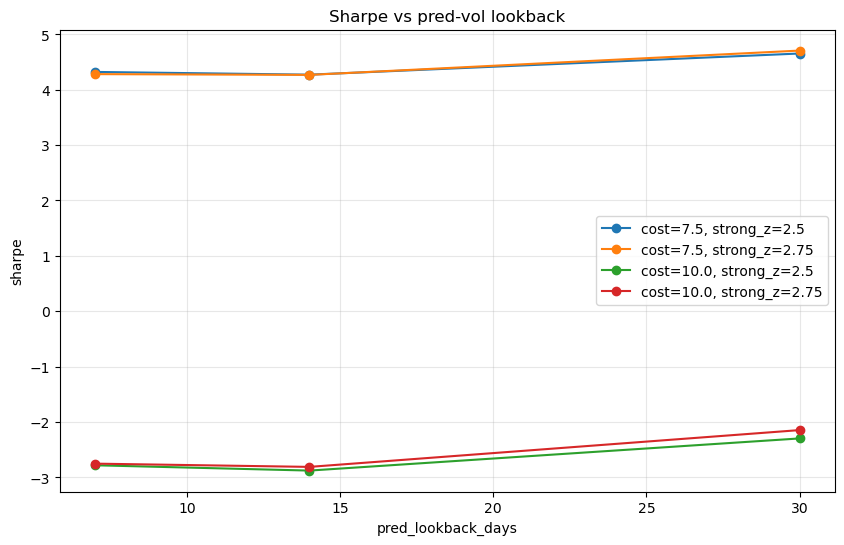

In [152]:
# Plot 1: Sharpe vs pred-vol lookback
plt.figure(figsize=(10, 6))
for (cost_bps, strong_z), g in marginal_lb_only.groupby(["cost_bps", "strong_z"]):
    g = g.sort_values("pred_lookback_days")
    plt.plot(
        g["pred_lookback_days"],
        g["sharpe"],
        marker="o",
        label=f"cost={cost_bps}, strong_z={strong_z}"
    )

plt.title("Sharpe vs pred-vol lookback")
plt.xlabel("pred_lookback_days")
plt.ylabel("sharpe")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

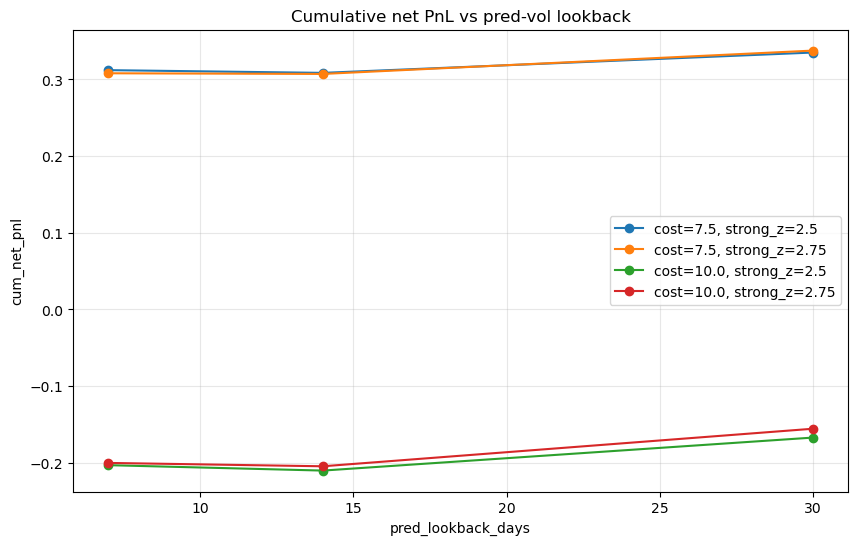

In [153]:
# Plot 2: Cum net pnl vs pred-vol lookback
plt.figure(figsize=(10, 6))
for (cost_bps, strong_z), g in marginal_lb_only.groupby(["cost_bps", "strong_z"]):
    g = g.sort_values("pred_lookback_days")
    plt.plot(
        g["pred_lookback_days"],
        g["cum_net_pnl"],
        marker="o",
        label=f"cost={cost_bps}, strong_z={strong_z}"
    )

plt.title("Cumulative net PnL vs pred-vol lookback")
plt.xlabel("pred_lookback_days")
plt.ylabel("cum_net_pnl")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

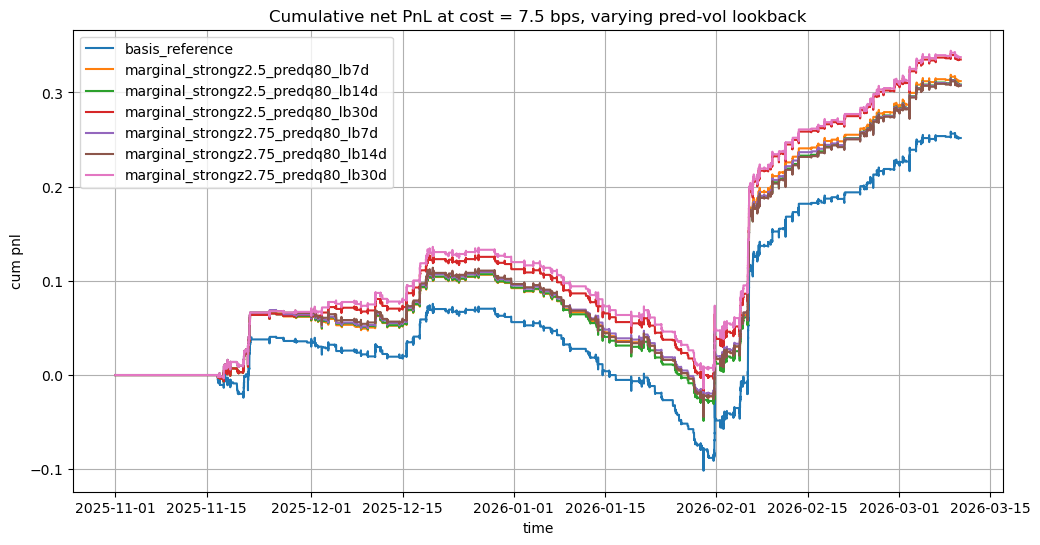

In [154]:
# Plot 4: cumulative PnL comparison at selected cost
plot_dict = {
    "basis_reference": bt_lb_store[f"basis_reference_cost{plot_cost_bps}"]
}

for strong_z in strong_z_list:
    for pred_lookback_days in pred_lookback_days_list:
        strategy_name = f"marginal_strongz{strong_z}_predq{int(pred_q*100)}_lb{pred_lookback_days}d"
        store_name = f"{strategy_name}_cost{plot_cost_bps}"
        plot_dict[strategy_name] = bt_lb_store[store_name]

plot_cum_pnl(
    plot_dict,
    pnl_col="net_pnl",
    title=f"Cumulative net PnL at cost = {plot_cost_bps} bps, varying pred-vol lookback"
)

In [155]:
#best rows by cost
best_rows = (
    relative_lb_table[relative_lb_table["strategy"] != "basis_reference"]
    .sort_values(["cost_bps", "delta_sharpe_vs_basis_ref"], ascending=[True, False])
    .groupby("cost_bps", as_index=False)
    .first()
)

best_rows

NameError: name 'relative_lb_table' is not defined